In [ ]:
import importlib.util
from pathlib import Path

import marimo as mo
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

from inwatch import canon
from inwatch.unidades import red_vial

# `vista.py` es un script hermano, no un módulo instalado: se carga por ruta para no
# depender del cwd ni de que el directorio del experimento esté en `sys.path`. Mismo
# mecanismo, y por el mismo motivo, que usa `capas.py` con el loader.
_spec = importlib.util.spec_from_file_location(
    "corredores_vista", Path(__file__).with_name("vista.py")
)
vista = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(vista)

In [ ]:
# ── Paleta ────────────────────────────────────────────────────────────────
# Un solo modo, claro, y a propósito: estas figuras son mapas de bits de matplotlib,
# no CSS; no siguen el tema del visor, así que la superficie se fija acá y el resto
# de los tonos se elige contra ella.
#
# Validada con el script del sistema de diseño (ΔE en OKLab bajo protanopía y
# deuteranopía, piso de visión normal y contraste contra la superficie):
#   · jerarquía vial, 3 pasos de un mismo azul, chequeo ordinal → todo PASA
#     (monótona, ΔL ≥ 0,06, extremo claro 2,06:1)
#   · {azul 450, naranja, aqua} en modo todos-contra-todos → todo PASA
#     (peor par naranja↔aqua ΔE 9,2 deutan, sobre el objetivo de 8; visión normal 19,2)
#   · naranja contra los tres pasos del azul: ΔE 23–28 deutan. No se confunden.
# El aqua y el paso claro quedan bajo 3:1 contra la superficie; la relajación exige
# etiqueta visible y la hay — los dos estadios van rotulados y el top va en tabla.
SUPERFICIE = "#fcfcfb"
TINTA = "#0b0b0b"
TINTA_2 = "#52514e"
MUTE = "#898781"
REJILLA = "#e1e0d9"

# Rampa secuencial de un solo tono, claro → oscuro. Magnitud, nunca identidad.
RAMPA = [
    "#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
    "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b",
]
CMAP = mcolors.LinearSegmentedColormap.from_list("inwatch_azul", RAMPA)
# Piso de la rampa para marcas puntuales: por debajo del paso 300 un punto sobre la
# superficie clara deja de verse, y "no se ve" no puede significar "vale poco".
PISO_PUNTO = 0.25

# La jerarquía vial es ORDINAL —una autopista no es "otra categoría" que una calle
# residencial, es un escalón más arriba—, así que va en un solo tono con la
# luminosidad cargando el orden.
COLOR_CLASE = {
    "arterial": "#104281",
    "secundaria": "#2a78d6",
    "local": "#86b6ef",
    # El busway sí es otra cosa, no otro escalón: sale de la rampa y toma el naranja,
    # que en todo el notebook significa transporte masivo (también las estaciones).
    "busway": "#eb6834",
    # Sin dato no es una clase baja: es gris y punteado. Deshilachado, nunca liso.
    "sin declarar": MUTE,
}
ANCHO_CLASE = {"arterial": 2.0, "secundaria": 1.2, "local": 0.5,
               "busway": 1.8, "sin declarar": 1.1}
TRAZO_CLASE = {"sin declarar": (0, (2.2, 2.2))}
ORDEN_DIBUJO = ("local", "secundaria", "arterial", "busway", "sin declarar")

# Capas de puntos: color + FORMA + etiqueta. Nunca color solo.
COLOR_CAPA = {"estacion": "#eb6834", "estadio": "#1baf7a"}
FORMA_CAPA = {"estacion": "s", "estadio": "^"}

In [ ]:
mo.md(
    f"""
    # Corredores críticos del eje Metropolitano centro-sur

    Qué tramos e intersecciones del área A concentran el **flujo potencial** de la
    red vial, medido con betweenness dirigida sobre
    {canon.display("corredores.conteo.nodos")} intersecciones y
    {canon.display("corredores.conteo.aristas")} aristas de la red `drive` de OSM.

    > ### Esto no mide tránsito
    > No hay aforos en ninguna de las fuentes. La betweenness cuenta **caminos
    > mínimos de la red**, sorteando origen y destino de manera uniforme entre
    > intersecciones: es una propiedad de la geometría del grafo, no una medición de
    > vehículos. Un tramo alto acá es un tramo por el que la red *obliga* a pasar, no
    > uno por el que se sabe que pasa gente. Nada de lo que sigue autoriza una frase
    > sobre congestión medida.

    **Sin datos ≠ seguro.** Los tramos sin medición se dibujan punteados y grises,
    nunca con el color del valor más bajo. Un cero sí es un dato y se dibuja como
    tal: son las calzadas paralelas que ningún camino mínimo usa.

    Mové el **peso** de abajo. Si el mapa se reordena, el corredor no era del eje: era
    del supuesto. La correlación entre las dos betweenness es de
    **{canon.display("corredores.corr.length_travel_time_tramos")}** (ρ de Spearman)
    en tramos y **{canon.display("corredores.corr.length_travel_time_nodos")}** en
    intersecciones.
    """
)

# Corredores críticos del eje Metropolitano centro-sur

Qué tramos e intersecciones del área A concentran el **flujo potencial** de la
red vial, medido con betweenness dirigida sobre
7559 intersecciones y
15813 aristas de la red `drive` de OSM.

> ### Esto no mide tránsito
> No hay aforos en ninguna de las fuentes. La betweenness cuenta **caminos
> mínimos de la red**, sorteando origen y destino de manera uniforme entre
> intersecciones: es una propiedad de la geometría del grafo, no una medición de
> vehículos. Un tramo alto acá es un tramo por el que la red *obliga* a pasar, no
> uno por el que se sabe que pasa gente. Nada de lo que sigue autoriza una frase
> sobre congestión medida.

**Sin datos ≠ seguro.** Los tramos sin medición se dibujan punteados y grises,
nunca con el color del valor más bajo. Un cero sí es un dato y se dibuja como
tal: son las calzadas paralelas que ningún camino mínimo usa.

Mové el **peso** de abajo. Si el mapa se reordena, el corredor no era del eje: era
del supuesto. La correlación entre las dos betweenness es de
**0.715** (ρ de Spearman)
en tramos y **0.764** en
intersecciones.

In [ ]:
mo.md(
    f"""
    ## 0 · El área, y cómo se llegó de OSM a este notebook

    **Área A**: Cercado de Lima, La Victoria, San Isidro, Miraflores y Surquillo, por
    UBIGEO, {canon.display("corredores.area.km2")} km² medidos en EPSG:32718 sobre el
    polígono que viaja en el repo. Por qué esta y no otra:

    - **Tiene un corredor declarado contra el cual leer el resultado.** El tramo
      centro-sur del Metropolitano la cruza de norte a sur y, con la Línea 1, deja
      {canon.display("corredores.conteo.estaciones_area_a")} estaciones adentro. Sin
      un corredor reconocido, "corredor crítico" no tendría con qué contrastarse.
    - **Tiene dos generadores de viajes puntuales**, los estadios Nacional y Matute,
      que entran como capa complementaria.
    - **Cabe el cálculo exacto.** {canon.display("corredores.conteo.nodos")}
      intersecciones y {canon.display("corredores.conteo.aristas")} aristas: sobre el
      mínimo del enunciado (3 000 y 6 000) y lejos del máximo recomendado (60 000). La
      betweenness exacta cuesta minutos, así que el resultado no depende de muestreo.
    - **`drive`**, porque el tema es tránsito vehicular: el enunciado lo exige para esos
      temas y reserva `walk` para accesibilidad peatonal.

    Cada etapa del pipeline es un script que deja artefactos en disco y emite sus cifras
    a un registro con procedencia (commit y hash del script y de los insumos). El texto
    de este notebook no escribe ningún número a mano: los pide al registro.
    """
)

## 0 · El área, y cómo se llegó de OSM a este notebook

**Área A**: Cercado de Lima, La Victoria, San Isidro, Miraflores y Surquillo, por
UBIGEO, 54.2 km² medidos en EPSG:32718 sobre el
polígono que viaja en el repo. Por qué esta y no otra:

- **Tiene un corredor declarado contra el cual leer el resultado.** El tramo
  centro-sur del Metropolitano la cruza de norte a sur y, con la Línea 1, deja
  20 estaciones adentro. Sin
  un corredor reconocido, "corredor crítico" no tendría con qué contrastarse.
- **Tiene dos generadores de viajes puntuales**, los estadios Nacional y Matute,
  que entran como capa complementaria.
- **Cabe el cálculo exacto.** 7559
  intersecciones y 15813 aristas: sobre el
  mínimo del enunciado (3 000 y 6 000) y lejos del máximo recomendado (60 000). La
  betweenness exacta cuesta minutos, así que el resultado no depende de muestreo.
- **`drive`**, porque el tema es tránsito vehicular: el enunciado lo exige para esos
  temas y reserva `walk` para accesibilidad peatonal.

Cada etapa del pipeline es un script que deja artefactos en disco y emite sus cifras
a un registro con procedencia (commit y hash del script y de los insumos). El texto
de este notebook no escribe ningún número a mano: los pide al registro.

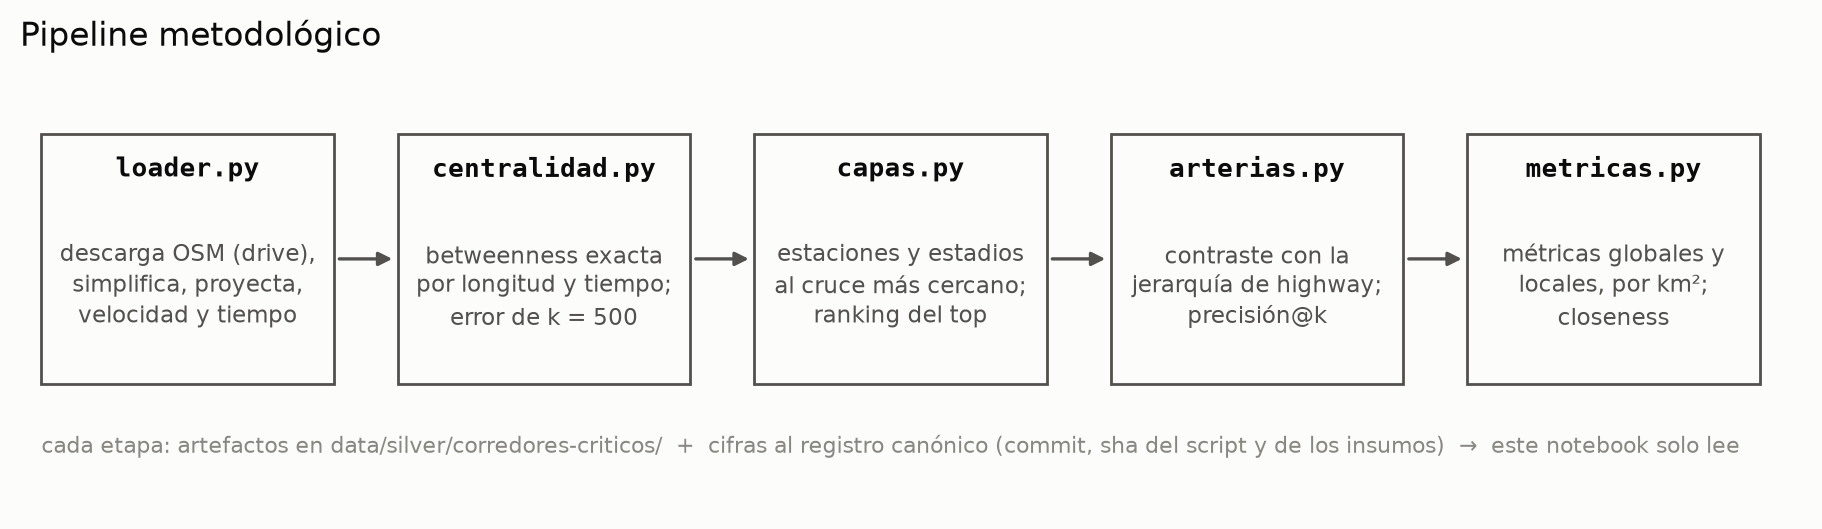

In [ ]:
# ── El pipeline metodológico, como figura ─────────────────────────────────
# Matplotlib y no mermaid: la figura tiene que sobrevivir al export a .ipynb y al
# informe en PDF, donde un diagrama que se dibuja con JavaScript no aparece.
_etapas = [
    ("loader.py", "descarga OSM (drive),\nsimplifica, proyecta,\nvelocidad y tiempo"),
    ("centralidad.py", "betweenness exacta\npor longitud y tiempo;\nerror de k = 500"),
    ("capas.py", "estaciones y estadios\nal cruce más cercano;\nranking del top"),
    ("arterias.py", "contraste con la\njerarquía de highway;\nprecisión@k"),
    ("metricas.py", "métricas globales y\nlocales, por km²;\ncloseness"),
]
fig_pipeline, _ax = plt.subplots(figsize=(11.5, 2.9))
fig_pipeline.patch.set_facecolor(SUPERFICIE)
_ax.set_facecolor(SUPERFICIE)
_ax.set_xlim(0, len(_etapas))
_ax.set_ylim(0, 1)
_ax.set_axis_off()
for _i, (_script, _que) in enumerate(_etapas):
    _ax.add_patch(plt.Rectangle((_i + 0.06, 0.28), 0.82, 0.56, facecolor=SUPERFICIE,
                                edgecolor=TINTA_2, lw=1.0))
    _ax.text(_i + 0.47, 0.76, _script, ha="center", va="center", color=TINTA,
             fontsize=9.5, fontweight="bold", family="monospace")
    _ax.text(_i + 0.47, 0.50, _que, ha="center", va="center", color=TINTA_2,
             fontsize=8.2, linespacing=1.35)
    if _i < len(_etapas) - 1:
        _ax.annotate("", xy=(_i + 1.06, 0.56), xytext=(_i + 0.88, 0.56),
                     arrowprops={"arrowstyle": "-|>", "color": TINTA_2, "lw": 1.2})
_ax.text(0.06, 0.14, "cada etapa: artefactos en data/silver/corredores-criticos/  "
         "+  cifras al registro canónico (commit, sha del script y de los insumos)  "
         "→  este notebook solo lee", color=MUTE, fontsize=8, ha="left", va="center")
_ax.set_title("Pipeline metodológico", color=TINTA, fontsize=12, loc="left")
fig_pipeline

In [ ]:
SLUG = "corredores-criticos"
_dir = Path(__file__).resolve().parents[2] / "data" / "silver" / SLUG

def _ruta(nombre: str) -> Path:
    ruta = _dir / nombre
    if not ruta.exists():
        raise FileNotFoundError(
            f"falta el artefacto: {ruta}\n"
            f"  corré, en orden:\n"
            f"    uv run --extra geo python experiments/{SLUG}/loader.py\n"
            f"    uv run --extra geo python experiments/{SLUG}/centralidad.py\n"
            f"    uv run --extra geo python experiments/{SLUG}/capas.py\n"
            f"    uv run --extra geo python experiments/{SLUG}/arterias.py\n"
            f"    uv run --extra geo python experiments/{SLUG}/metricas.py"
        )
    return ruta

# El GraphML es un artefacto como cualquier otro; `tramos` e `intersecciones` solo
# desenrollan la geometría que ya está adentro, proyectada en EPSG:32718.
_G, meta_grafo = red_vial.cargar(_ruta("area_a_drive.graphml"))
_tramos_geo = red_vial.tramos(_G)
_inter_geo = red_vial.intersecciones(_G)

# `how="left"` desde la geometría: si un tramo no tuviera fila en la tabla de
# betweenness, queda en NaN y se dibuja deshilachado. Rellenarlo con 0 sería
# inventarle una medición.
tramos_bc = _tramos_geo.merge(pd.read_parquet(_ruta("betweenness_tramos.parquet")),
                              on="tramo_id", how="left")
inter_bc = _inter_geo.merge(pd.read_parquet(_ruta("betweenness_intersecciones.parquet")),
                            on="node_id", how="left")
capas_nodos = pd.read_parquet(_ruta("capas_asignadas.parquet"))
capas_tramos = pd.read_parquet(_ruta("capas_tramos_cercanos.parquet"))
rankings = {
    f"{unidad}_{peso}": pd.read_parquet(_ruta(f"ranking_{unidad}_{peso}.parquet"))
    for unidad in ("intersecciones", "tramos")
    for peso in ("length", "travel_time")
}
arterias_cls = pd.read_parquet(_ruta("arterias_clasificacion.parquet"))
arterias_curva = pd.read_parquet(_ruta("arterias_curva_coincidencia.parquet"))
metricas_nodos = _inter_geo[["node_id", "geometry"]].merge(
    pd.read_parquet(_ruta("metricas_intersecciones.parquet")), on="node_id", how="left"
)
orientacion = pd.read_parquet(_ruta("orientacion.parquet"))

In [ ]:
peso = mo.ui.radio(
    options={"longitud (metros)": "length", "tiempo de viaje (segundos)": "travel_time"},
    value="longitud (metros)",
    label="**peso** de los caminos mínimos",
)
# Hasta 300: el artefacto de ranking fija el top-100 y el deslizador tiene que poder
# pasarlo, para que se vea que el corte es una decisión y no un hecho de la red.
top = mo.ui.slider(
    start=10, stop=300, step=10, value=100,
    label="**tamaño del top**", show_value=True,
)
mo.hstack([peso, top], justify="start", gap=3)

<marimo-slider data-initial-value='100' data-label='"\u003cspan class=\"markdown prose dark:prose-invert contents\"\u003e\u003cspan class=\"paragraph\"\u003e\u003cstrong\u003etamaño del top\u003c/strong\u003e\u003c/span\u003e\u003c/span\u003e"' data-start='10' data-stop='300' data-step='10' data-steps='[]' data-debounce='false' data-disabled='false' data-orientation='"horizontal"' data-show-value='true' data-include-input='false' data-full-width='false'>

In [ ]:
COLUMNA = f"bc_{peso.value}"
ETIQUETA_PESO = {"length": "longitud", "travel_time": "tiempo de viaje"}[peso.value]

# El top se deriva de la tabla de betweenness con el mismo desempate por clave que
# usa `capas.ranking`, porque acá el tamaño lo mueve un deslizador y el artefacto
# solo trae el top-100. Más abajo se comprueba que las dos rutas coinciden.
top_tramos = vista.tabla_top(tramos_bc.drop(columns="geometry"),
                             columna=COLUMNA, clave="tramo_id", top=top.value)
top_inter = vista.tabla_top(inter_bc.drop(columns="geometry"),
                            columna=COLUMNA, clave="node_id", top=top.value)

# Capas cerca de cada unidad del top. Un punto marcado `fuera_de_rango` quedó a más
# de medio kilómetro de cualquier intersección: no se le cuelga una, se lo declara.
nodos_con_capa = set(capas_nodos.loc[~capas_nodos["fuera_de_rango"], "node_id"].astype(str))
tramos_con_capa = set(capas_tramos["tramo_id"].astype(str))

In [ ]:
# ── Cromo compartido de los tres mapas ────────────────────────────────────
def marco_mapa(figsize=(11.5, 8.5)):
    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(SUPERFICIE)
    ax.set_facecolor(SUPERFICIE)
    ax.set_aspect("equal")
    ax.set_axis_off()
    return fig, ax

def escala_y_norte(ax, *, titulo, subtitulo):
    """Barra de escala, flecha de norte y títulos. Los tres mapas llevan los tres.

    El mapa se dibuja en EPSG:32718, donde una unidad de los ejes **es** un metro:
    la barra se mide en coordenadas de datos, sin factor que estimar. El norte que
    marca la flecha es el de la cuadrícula UTM, que en Lima se desvía del geográfico
    menos de medio grado — se dice en la nota en vez de dibujar una flecha que
    sugiere una precisión que la proyección no tiene.
    """
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    ancho, alto = x1 - x0, y1 - y0
    mx, my = 0.04 * ancho, 0.04 * alto

    largo = vista.longitud_barra(ancho)
    bx, by = x0 + mx, y0 + my
    grosor = 0.006 * alto
    # Barra de dos tramos, el clásico damero: el borde marca el medio sin depender
    # de que se lea un número chico.
    for i, color in enumerate((TINTA, SUPERFICIE)):
        ax.add_patch(plt.Rectangle((bx + i * largo / 2, by), largo / 2, grosor,
                                   facecolor=color, edgecolor=TINTA, lw=0.8, zorder=6))
    # El "0" alineado a la izquierda y no centrado: con la barra pegada al margen,
    # centrarlo lo deja medio fuera del recorte de la figura.
    ax.text(bx, by + grosor * 2.4, "0", color=TINTA_2, fontsize=8, ha="left")
    ax.text(bx + largo, by + grosor * 2.4,
            f"{largo / 1000:g} km" if largo >= 1000 else f"{largo:g} m",
            color=TINTA_2, fontsize=8, ha="center")

    nx, ny = x1 - mx, y1 - my
    ax.annotate("", xy=(nx, ny), xytext=(nx, ny - 0.07 * alto), zorder=6,
                arrowprops={"arrowstyle": "-|>", "color": TINTA, "lw": 1.5,
                            "shrinkA": 0, "shrinkB": 0})
    ax.text(nx, ny + 0.008 * alto, "N", color=TINTA, fontsize=10,
            fontweight="bold", ha="center", va="bottom", zorder=6)

    ax.set_title(titulo, color=TINTA, fontsize=13, loc="left", pad=24)
    ax.text(0.0, 1.004, subtitulo, transform=ax.transAxes, color=TINTA_2,
            fontsize=9, ha="left", va="bottom")
    ax.text(1.0, -0.01, "EPSG:32718 · norte de cuadrícula UTM 18S · "
                        "© OpenStreetMap contributors (ODbL)",
            transform=ax.transAxes, color=MUTE, fontsize=7.5, ha="right", va="top")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

def leyenda(ax, entradas, *, titulo=None):
    leg = ax.legend(handles=entradas, title=titulo, loc="lower right",
                    frameon=True, framealpha=0.94, fontsize=8.5,
                    facecolor=SUPERFICIE, edgecolor=MUTE, labelcolor=TINTA_2)
    leg.get_frame().set_linewidth(0.6)
    if titulo:
        leg.get_title().set_color(TINTA)
        leg.get_title().set_fontsize(9)
    return leg

## 1 · La red y las arterias que OSM ya declara

El primer mapa no calcula nada: dibuja la jerarquía que viene etiquetada en el
dato. Es la referencia contra la que se lee todo lo demás — si los corredores que
salgan de la betweenness coincidieran punto por punto con este mapa, el cálculo no
estaría aportando nada que OSM no dijera ya.

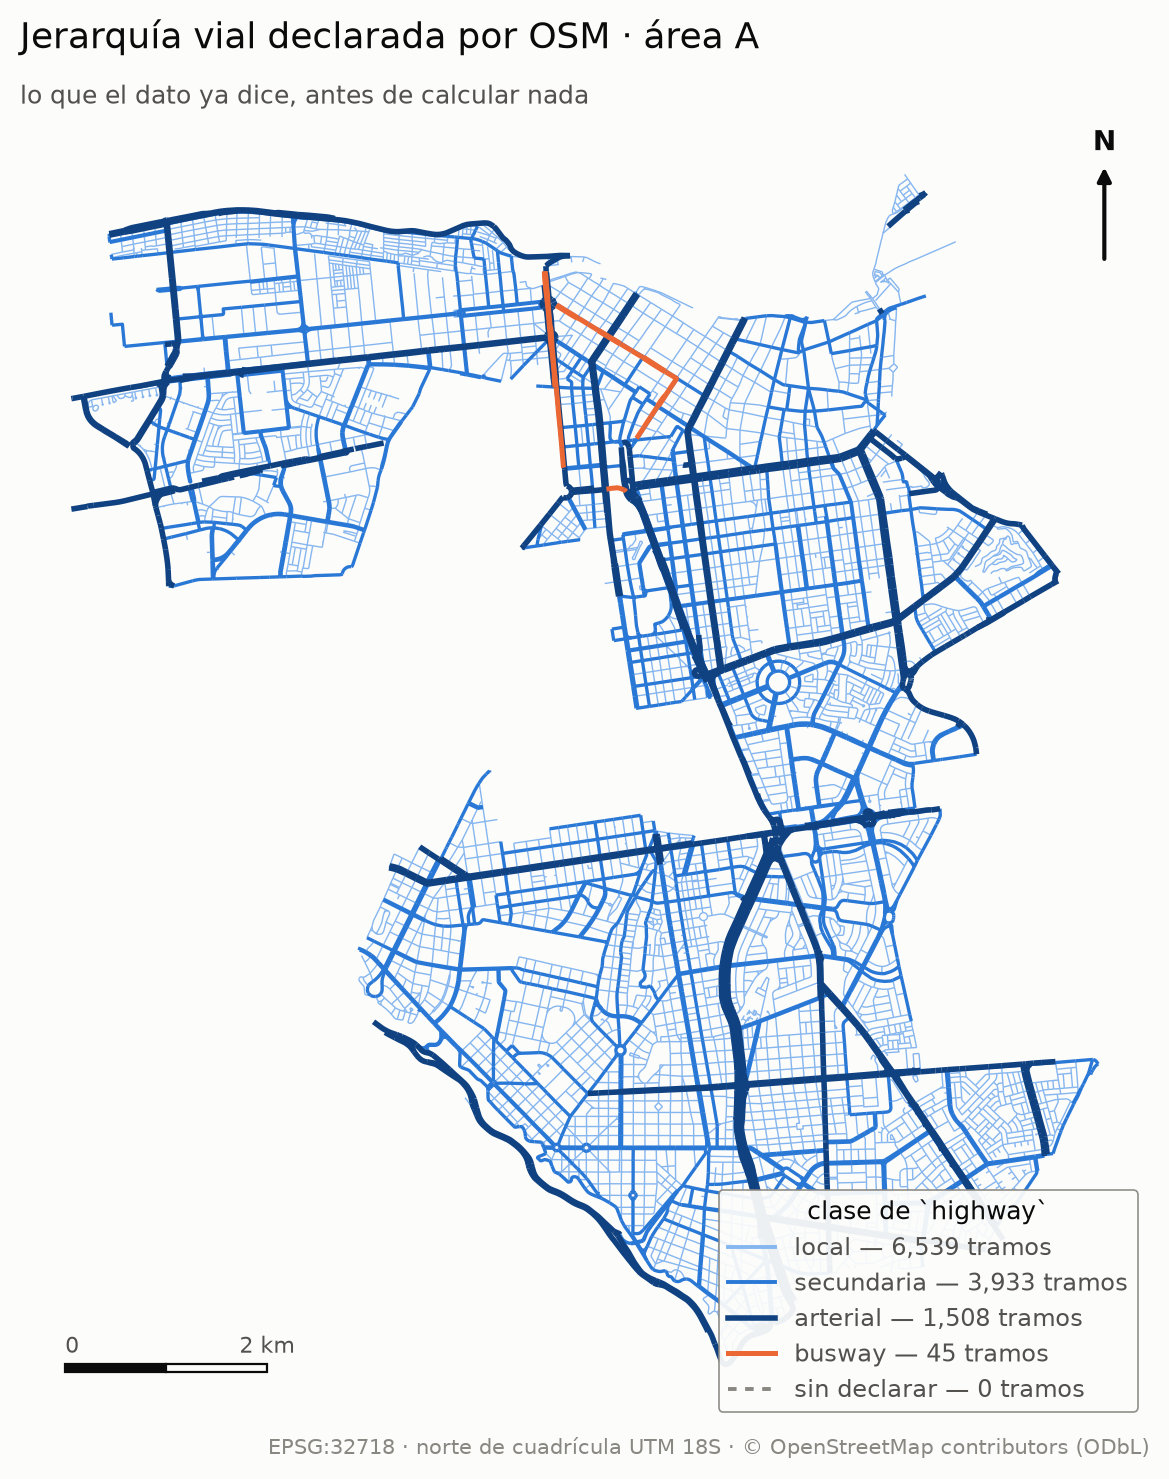

In [ ]:
_clase = vista.clasificar(tramos_bc)
fig_red, _ax = marco_mapa()

_entradas = []
for _c in ORDEN_DIBUJO:
    _sel = tramos_bc[(_clase == _c).to_numpy()]
    _trazo = TRAZO_CLASE.get(_c, "solid")
    if not _sel.empty:
        _sel.plot(ax=_ax, color=COLOR_CLASE[_c], linewidth=ANCHO_CLASE[_c],
                  linestyle=_trazo, zorder=2 + ORDEN_DIBUJO.index(_c))
    # La entrada va a la leyenda aunque la clase esté vacía: un "0 tramos" visible
    # dice que la categoría se buscó, que es distinto de que nunca se haya mirado.
    _entradas.append(Line2D([0], [0], color=COLOR_CLASE[_c],
                            lw=max(ANCHO_CLASE[_c], 1.4), linestyle=_trazo,
                            label=f"{_c} — {len(_sel):,} tramos"))

escala_y_norte(
    _ax,
    titulo="Jerarquía vial declarada por OSM · área A",
    subtitulo="lo que el dato ya dice, antes de calcular nada",
)
leyenda(_ax, _entradas, titulo="clase de `highway`")
fig_red

In [ ]:
mo.md(
    f"""
    El grafo llega simplificado: `simplify=True` disuelve los nodos que solo existen
    para doblar la geometría y deja
    **{canon.display("corredores.pct.reduccion_simplificacion")} %** menos
    intersecciones que la descarga cruda. Lo que queda son cruces, que es la unidad
    que el contrato llama `interseccion`.

    Lo que el dato no trae, y hay que declarar antes de usarlo:
    **{canon.display("corredores.pct.sin_maxspeed")} %** de los tramos no tiene
    `maxspeed`, **{canon.display("corredores.pct.sin_lanes")} %** no tiene `lanes` y
    **{canon.display("corredores.pct.sin_name")} %** no tiene nombre. osmnx completa
    la velocidad que falta con la media de su tipo de vía, y así queda imputada la
    velocidad del **{canon.display("corredores.pct.maxspeed_imputado_aristas")} %**
    de las aristas — el
    **{canon.display("corredores.pct.maxspeed_imputado_largo")} %** de la longitud de
    la red. **Todo lo que salga del peso por tiempo de viaje hereda ese supuesto.**

    Foto de OSM usada: `{meta_grafo["consulta"]}`, descargada el
    `{meta_grafo["descargado_en"][:10]}` con osmnx
    `{meta_grafo["versiones"]["osmnx"]}`.
    """
)

El grafo llega simplificado: `simplify=True` disuelve los nodos que solo existen
para doblar la geometría y deja
**76.7 %** menos
intersecciones que la descarga cruda. Lo que queda son cruces, que es la unidad
que el contrato llama `interseccion`.

Lo que el dato no trae, y hay que declarar antes de usarlo:
**23.0 %** de los tramos no tiene
`maxspeed`, **35.4 %** no tiene `lanes` y
**6.0 %** no tiene nombre. osmnx completa
la velocidad que falta con la media de su tipo de vía, y así queda imputada la
velocidad del **30.1 %**
de las aristas — el
**25.1 %** de la longitud de
la red. **Todo lo que salga del peso por tiempo de viaje hereda ese supuesto.**

Foto de OSM usada: `ox.graph_from_polygon(unión de UBIGEO 150101, 150115, 150131, 150122, 150141 de la fuente distritos_limites_area_a, network_type='drive', simplify=True, retain_all=False)`, descargada el
`2026-09-15` con osmnx
`2.1.1`.

In [ ]:
def _c(clave):
    return canon.display(clave)

mo.md(
    f"""
    ## 1b · La forma de la red, antes de preguntarle por corredores

    Las métricas globales que la hacen interpretable, normalizadas por área donde
    dependen de la escala. Salen de `metricas.py` y del registro.

    | Métrica | Valor |
    |---|---|
    | Intersecciones por km² | {_c("corredores.area.intersecciones_por_km2")} |
    | km de calle por km² | {_c("corredores.area.km_calle_por_km2")} |
    | Densidad dirigida m/n(n−1), ×10⁴ | {_c("corredores.red.densidad_x1e4")} |
    | Arcos salientes por intersección | {_c("corredores.red.grado_medio_salida")} |
    | Calles por intersección (`street_count`) | {_c("corredores.red.calles_por_nodo")} |
    | Componentes fuertemente conexas | {_c("corredores.conteo.scc")} |
    | Nodos en la componente fuerte gigante | {_c("corredores.pct.nodos_scc_gigante")} % |
    | Circuidad (Σ largo / Σ recta) | {_c("corredores.red.circuidad")} |
    | Orden φ (0 aleatoria, 1 grilla) | {_c("corredores.red.orientacion_orden")} |
    | Clustering medio | {_c("corredores.red.clustering_medio")} |

    La densidad casi nula es lo esperable en una red plana: cada cruce toca unas tres
    calles sin importar cuántas haya, así que la densidad cae con n y la comparación
    útil es por km². Las componentes fuertes que sobran son nodos que los sentidos
    únicos dejan sin retorno. La circuidad cerca de 1 dice que las calles son casi
    rectas; φ cerca de 0, que no forman una sola grilla, y por eso el camino mínimo
    tiene que elegir corredor.
    """
)

## 1b · La forma de la red, antes de preguntarle por corredores

Las métricas globales que la hacen interpretable, normalizadas por área donde
dependen de la escala. Salen de `metricas.py` y del registro.

| Métrica | Valor |
|---|---|
| Intersecciones por km² | 131.1 |
| km de calle por km² | 19.1 |
| Densidad dirigida m/n(n−1), ×10⁴ | 2.768 |
| Arcos salientes por intersección | 2.092 |
| Calles por intersección (`street_count`) | 3.233 |
| Componentes fuertemente conexas | 144 |
| Nodos en la componente fuerte gigante | 97.2 % |
| Circuidad (Σ largo / Σ recta) | 1.018 |
| Orden φ (0 aleatoria, 1 grilla) | 0.208 |
| Clustering medio | 0.040 |

La densidad casi nula es lo esperable en una red plana: cada cruce toca unas tres
calles sin importar cuántas haya, así que la densidad cae con n y la comparación
útil es por km². Las componentes fuertes que sobran son nodos que los sentidos
únicos dejan sin retorno. La circuidad cerca de 1 dice que las calles son casi
rectas; φ cerca de 0, que no forman una sola grilla, y por eso el camino mínimo
tiene que elegir corredor.

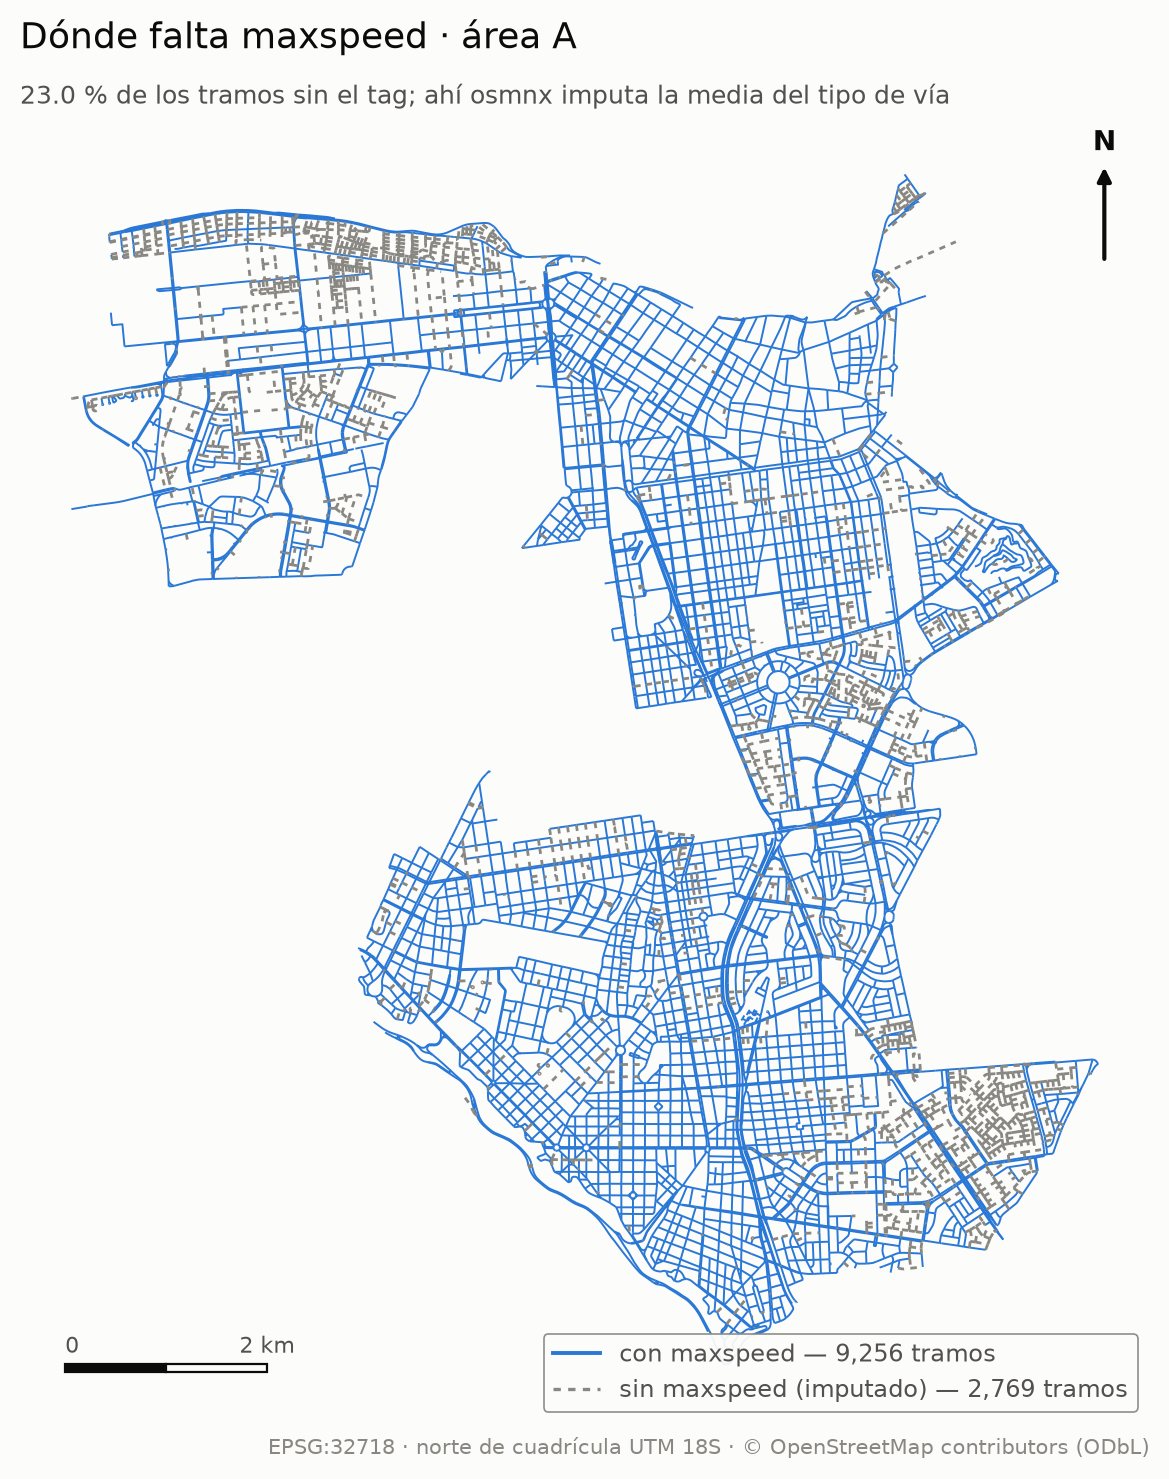

In [ ]:
# ── EDA espacial: dónde falta el dato que el peso por tiempo necesita ─────
_sin = tramos_bc["maxspeed"].isna().to_numpy()
fig_faltantes, _ax = marco_mapa()
tramos_bc[~_sin].plot(ax=_ax, color=COLOR_CLASE["secundaria"], linewidth=0.7, zorder=2)
tramos_bc[_sin].plot(ax=_ax, color=MUTE, linewidth=1.0, linestyle=(0, (2.2, 2.2)),
                     zorder=3)
escala_y_norte(
    _ax,
    titulo="Dónde falta maxspeed · área A",
    subtitulo=(f"{canon.display('corredores.pct.sin_maxspeed')} % de los tramos sin el "
               "tag; ahí osmnx imputa la media del tipo de vía"),
)
leyenda(_ax, [
    Line2D([0], [0], color=COLOR_CLASE["secundaria"], lw=1.4,
           label=f"con maxspeed — {int((~_sin).sum()):,} tramos"),
    Line2D([0], [0], color=MUTE, lw=1.2, linestyle=(0, (2.2, 2.2)),
           label=f"sin maxspeed (imputado) — {int(_sin.sum()):,} tramos"),
])
fig_faltantes

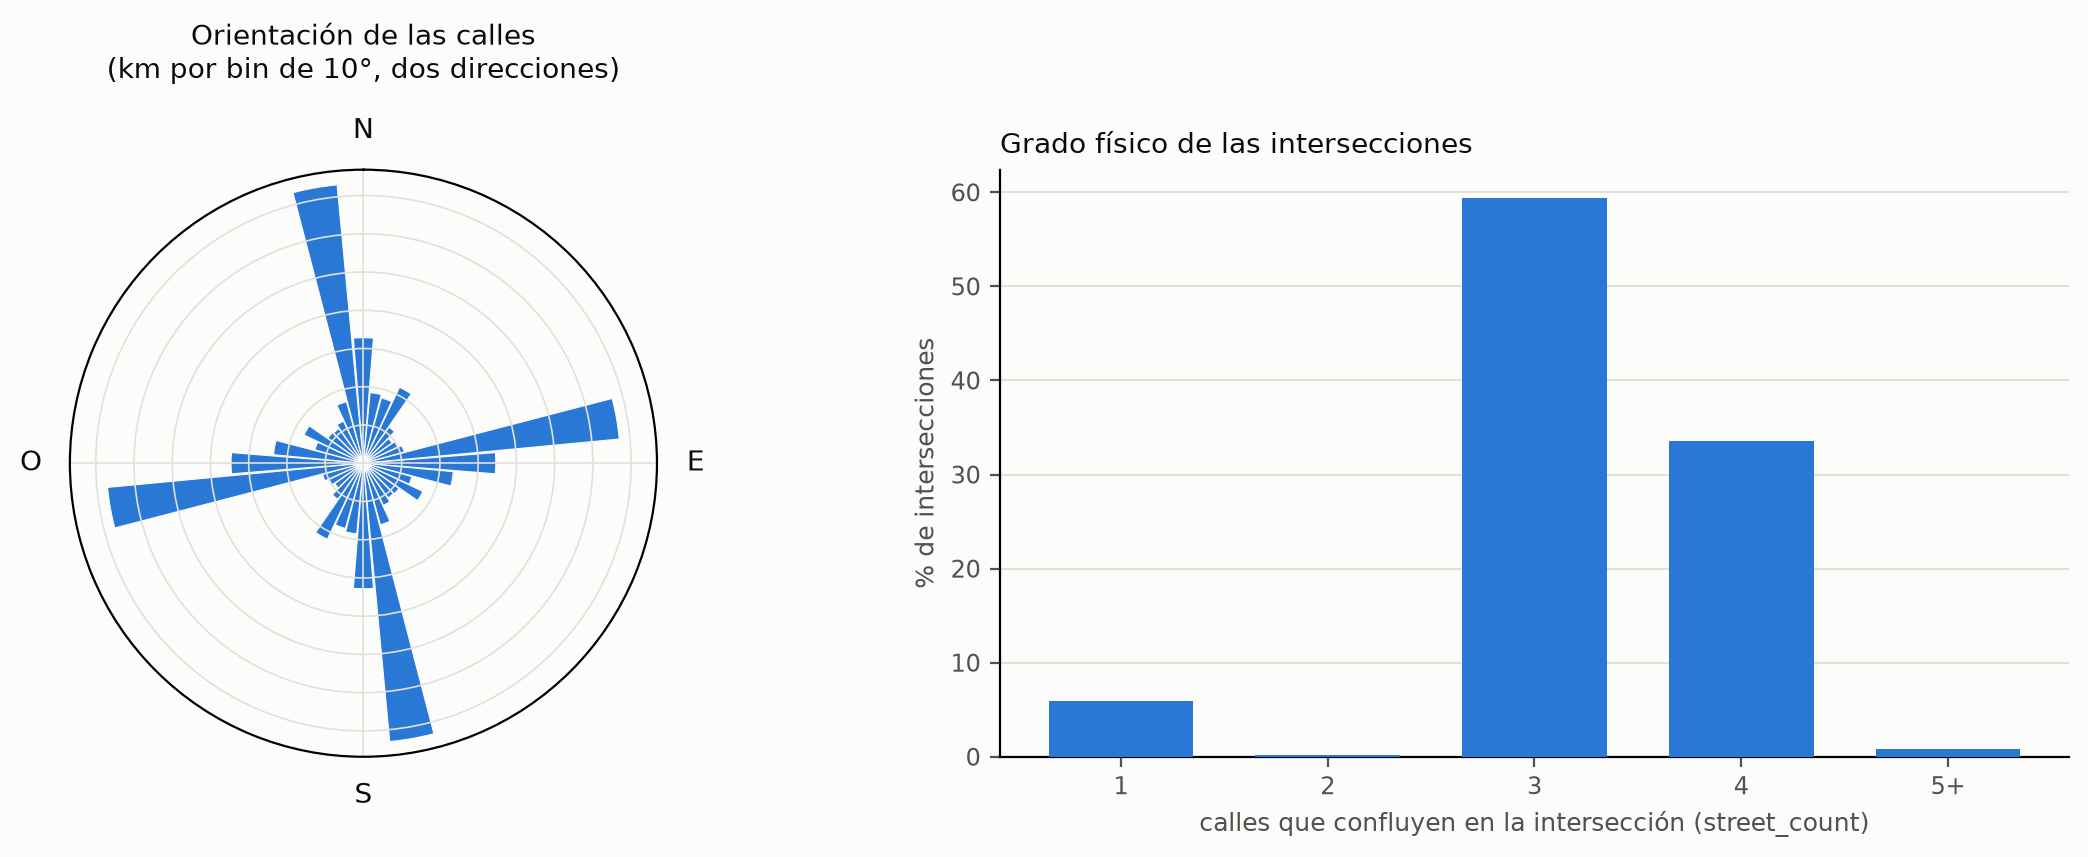

In [ ]:
# ── Orientación y grado físico ────────────────────────────────────────────
fig_forma = plt.figure(figsize=(11.5, 4.4))
fig_forma.patch.set_facecolor(SUPERFICIE)

_polar = fig_forma.add_subplot(1, 2, 1, projection="polar")
_polar.set_facecolor(SUPERFICIE)
_theta = np.radians(orientacion["bin_centro_grados"].to_numpy())
_masa = orientacion["masa_m"].to_numpy() / 1000
_polar.bar(_theta, _masa, width=2 * np.pi / len(_theta) * 0.92,
           color=COLOR_CLASE["secundaria"], edgecolor=SUPERFICIE, lw=0.4)
_polar.set_theta_zero_location("N")
_polar.set_theta_direction(-1)
_polar.set_xticks(np.radians([0, 90, 180, 270]), ["N", "E", "S", "O"], color=TINTA)
_polar.set_yticklabels([])
_polar.grid(color=REJILLA, lw=0.6)
_polar.set_title("Orientación de las calles\n(km por bin de 10°, dos direcciones)",
                 color=TINTA, fontsize=10, pad=14)

_barras = fig_forma.add_subplot(1, 2, 2)
_barras.set_facecolor(SUPERFICIE)
_cuenta = metricas_nodos["street_count"].clip(upper=5).value_counts().sort_index()
_etiquetas = [("5+" if k == 5 else str(int(k))) for k in _cuenta.index]
_barras.bar(_etiquetas, 100 * _cuenta.to_numpy() / _cuenta.sum(),
            color=COLOR_CLASE["secundaria"], width=0.7, zorder=3)
_barras.set_xlabel("calles que confluyen en la intersección (street_count)",
                   color=TINTA_2, fontsize=9)
_barras.set_ylabel("% de intersecciones", color=TINTA_2, fontsize=9)
_barras.set_title("Grado físico de las intersecciones", color=TINTA, fontsize=10,
                  loc="left")
_barras.grid(axis="y", color=REJILLA, lw=0.7, zorder=0)
_barras.tick_params(colors=TINTA_2, labelsize=8.5)
_barras.spines[["top", "right"]].set_visible(False)
fig_forma.tight_layout()
fig_forma

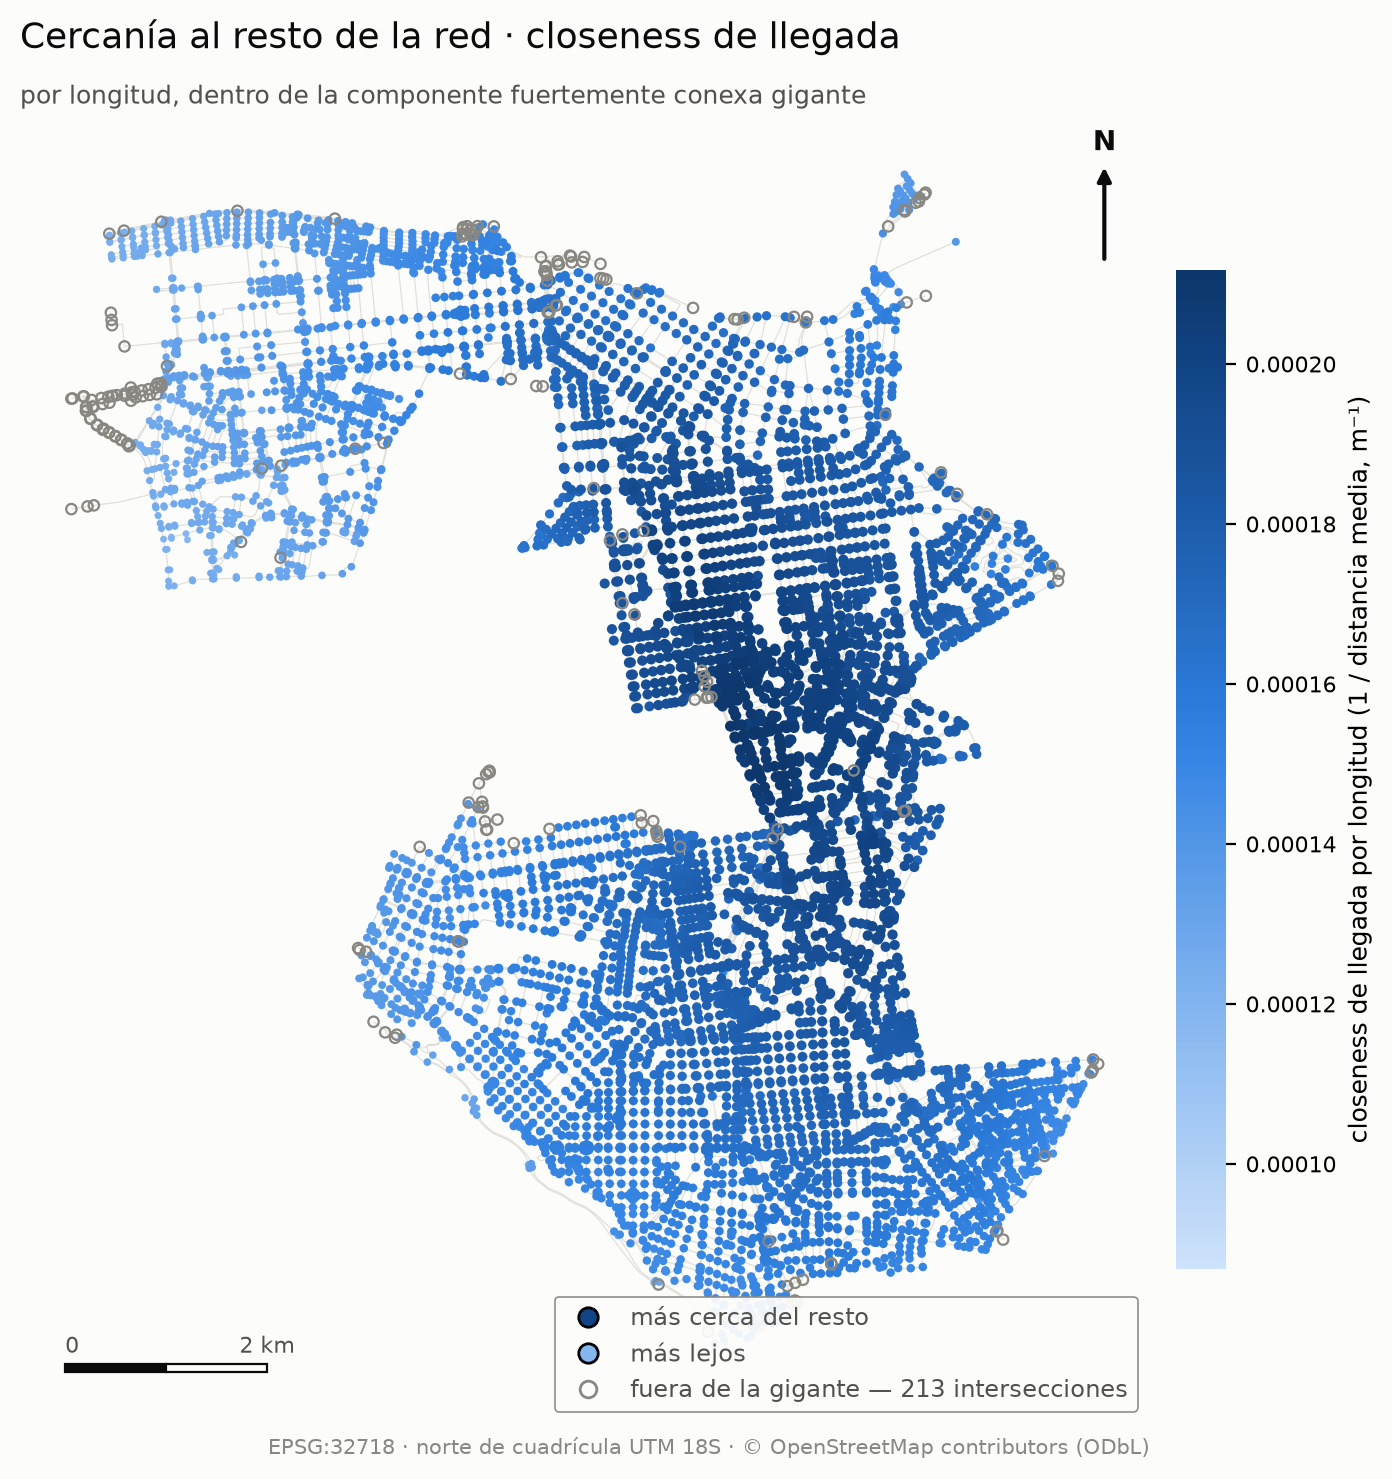

In [ ]:
# ── Métrica local: closeness de llegada, solo en la componente fuerte gigante ──
fig_closeness, _ax = marco_mapa()
tramos_bc.plot(ax=_ax, color=REJILLA, linewidth=0.45, zorder=1)
_dentro = metricas_nodos[metricas_nodos["en_scc_gigante"]].sort_values("closeness_length")
_fuera = metricas_nodos[~metricas_nodos["en_scc_gigante"]]
_v = vista.normalizar(_dentro["closeness_length"])
_ax.scatter(_dentro.geometry.x, _dentro.geometry.y, s=6 + 10 * _v,
            c=[CMAP(PISO_PUNTO + (1 - PISO_PUNTO) * x) for x in _v], linewidths=0,
            zorder=3)
# Fuera de la gigante la closeness no se define: punto hueco y gris, no el color bajo.
_ax.scatter(_fuera.geometry.x, _fuera.geometry.y, s=14, facecolors="none",
            edgecolors=MUTE, linewidths=0.8, zorder=4)
_lo = float(np.nanmin(_dentro["closeness_length"]))
_hi = float(np.nanmax(_dentro["closeness_length"]))
_cb = fig_closeness.colorbar(
    plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(vmin=_lo, vmax=_hi)),
    ax=_ax, fraction=0.028, pad=0.015,
)
_cb.set_label("closeness de llegada por longitud (1 / distancia media, m⁻¹)", fontsize=9)
_cb.ax.tick_params(labelsize=8)
_cb.outline.set_visible(False)
escala_y_norte(
    _ax,
    titulo="Cercanía al resto de la red · closeness de llegada",
    subtitulo="por longitud, dentro de la componente fuertemente conexa gigante",
)
leyenda(_ax, [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=CMAP(0.9), markersize=7,
           label="más cerca del resto"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=CMAP(PISO_PUNTO),
           markersize=7, label="más lejos"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="none",
           markeredgecolor=MUTE, markersize=6,
           label=f"fuera de la gigante — {len(_fuera):,} intersecciones"),
])
fig_closeness

In [ ]:
mo.md(
    f"""
    La closeness premia estar en el **centro geográfico**; la betweenness, estar en el
    **paso obligado** entre zonas. Dentro de la componente gigante casi no ordenan
    igual: ρ de Spearman =
    **{canon.display("corredores.corr.closeness_betweenness_nodos")}**. El mapa de
    arriba es una mancha que se aclara hacia los bordes; el de betweenness que sigue es
    un puñado de líneas. Un corredor crítico se define por lo segundo.
    """
)

La closeness premia estar en el **centro geográfico**; la betweenness, estar en el
**paso obligado** entre zonas. Dentro de la componente gigante casi no ordenan
igual: ρ de Spearman =
**0.241**. El mapa de
arriba es una mancha que se aclara hacia los bordes; el de betweenness que sigue es
un puñado de líneas. Un corredor crítico se define por lo segundo.

In [ ]:
mo.md(
    f"""
    ## 2 · La betweenness de los tramos

    Ahora sí el cálculo. Cada tramo se pinta por cuántos caminos mínimos de la red
    pasan por él, con el peso en **{ETIQUETA_PESO}**. Cambiá el selector de arriba y
    mirá el sur del área: por longitud el corredor busca la ruta corta, por tiempo se
    va a la vía rápida, y no son la misma calle.
    """
)

## 2 · La betweenness de los tramos

Ahora sí el cálculo. Cada tramo se pinta por cuántos caminos mínimos de la red
pasan por él, con el peso en **longitud**. Cambiá el selector de arriba y
mirá el sur del área: por longitud el corredor busca la ruta corta, por tiempo se
va a la vía rápida, y no son la misma calle.

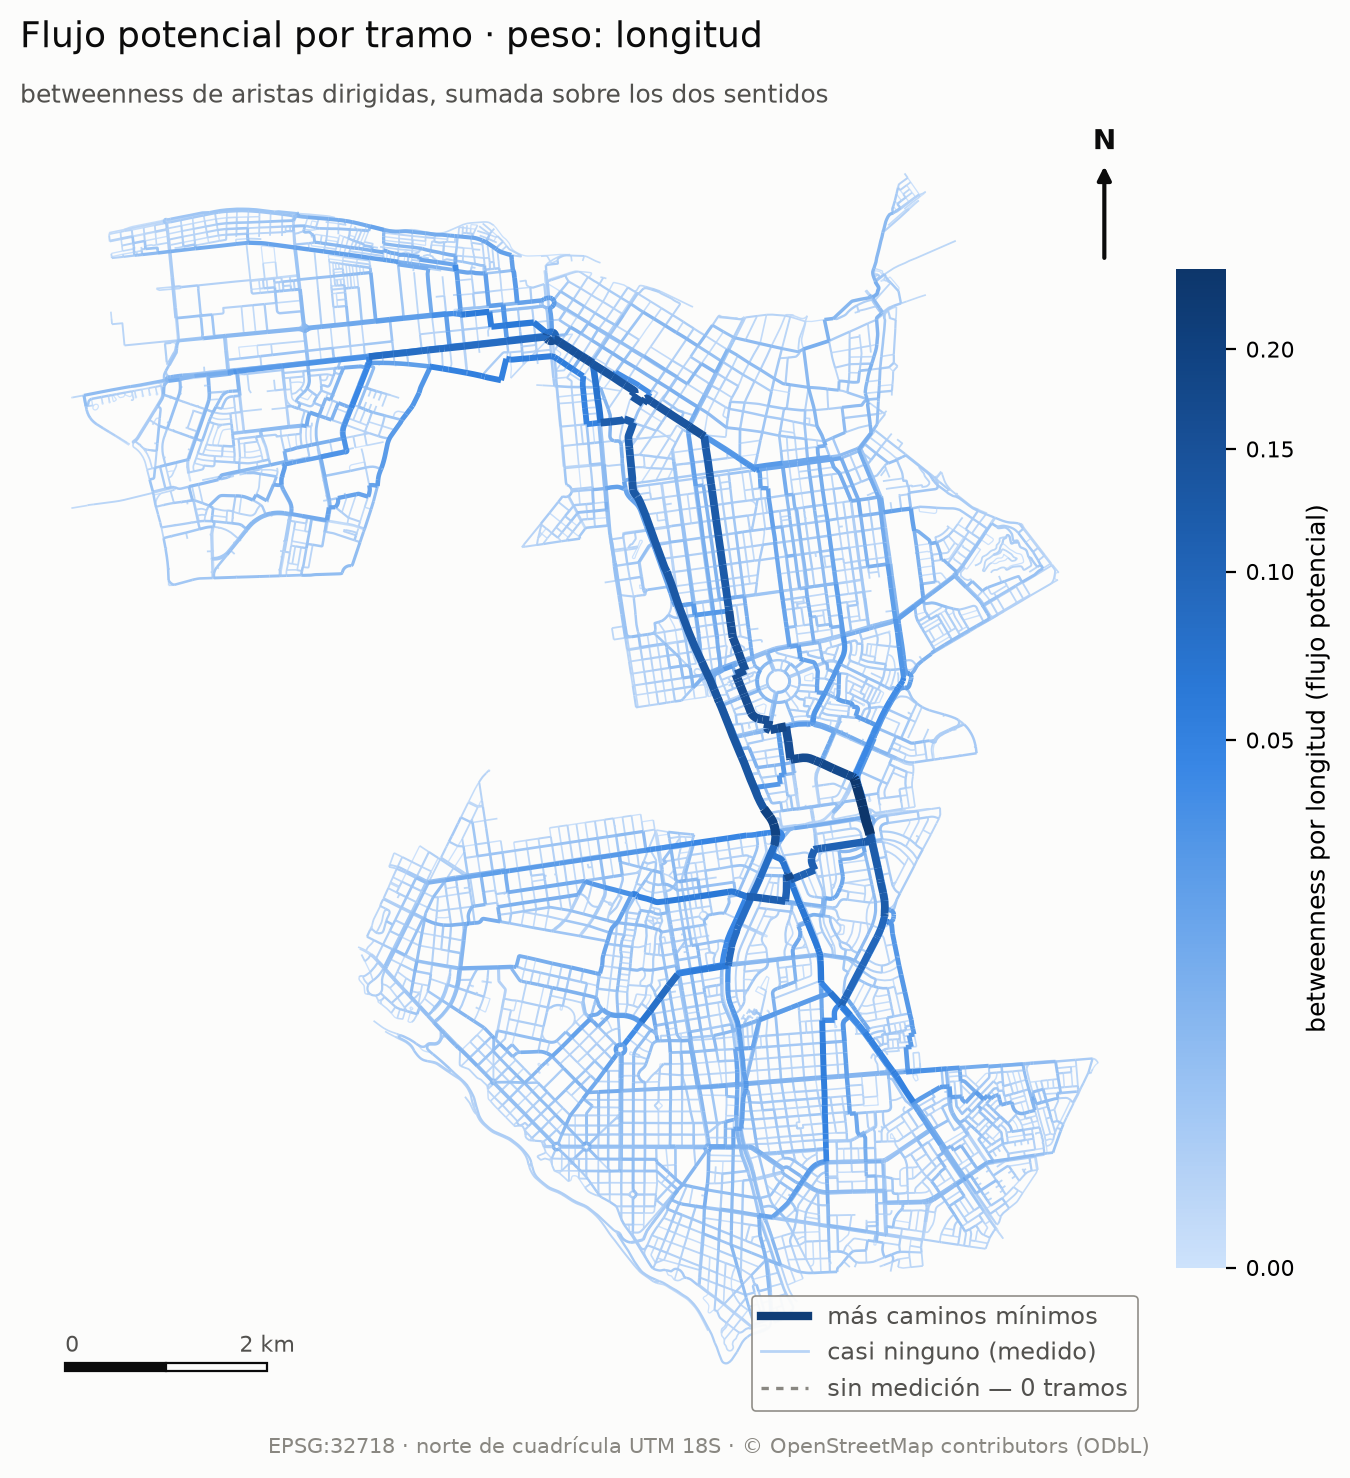

In [ ]:
_hueco = vista.sin_dato(tramos_bc, COLUMNA).to_numpy()
_norm01 = vista.normalizar(tramos_bc[COLUMNA], gamma=vista.GAMMA_BC)

fig_bc, _ax = marco_mapa()

# Primero lo que no tiene medición, debajo y punteado. No es el fondo del mapa: es
# una capa con su entrada en la leyenda.
if _hueco.any():
    tramos_bc[_hueco].plot(ax=_ax, color=MUTE, linewidth=1.0,
                           linestyle=(0, (2.2, 2.2)), zorder=2)

# Lo medido, de menor a mayor, para que el corredor quede encima de la trama y no
# tapado por ella. El ancho acompaña al color: la magnitud va por dos canales.
_con = tramos_bc[~_hueco].copy()
_v = _norm01[~_hueco]
_orden = np.argsort(_v, kind="stable")
_con = _con.iloc[_orden]
_v = _v[_orden]
_con.plot(ax=_ax, color=[CMAP(x) for x in _v], linewidth=(0.45 + 3.1 * _v).tolist(),
          zorder=3)

# `PowerNorm(gamma)` es, por definición, ((v−vmin)/(vmax−vmin))**gamma: la misma
# transformación que `vista.normalizar`. Por eso la barra puede llevar los valores
# reales en su posición correcta, y el gamma comprime la cola sin deformar el eje.
_lo = float(np.nanmin(tramos_bc[COLUMNA]))
_hi = float(np.nanmax(tramos_bc[COLUMNA]))
_barra = plt.cm.ScalarMappable(
    cmap=CMAP, norm=mcolors.PowerNorm(gamma=vista.GAMMA_BC, vmin=_lo, vmax=_hi)
)
_cb = fig_bc.colorbar(_barra, ax=_ax, fraction=0.028, pad=0.015)
_cb.set_label(f"betweenness por {ETIQUETA_PESO} (flujo potencial)", fontsize=9)
_cb.ax.tick_params(labelsize=8)
_cb.outline.set_visible(False)

escala_y_norte(
    _ax,
    titulo=f"Flujo potencial por tramo · peso: {ETIQUETA_PESO}",
    subtitulo="betweenness de aristas dirigidas, sumada sobre los dos sentidos",
)
leyenda(
    _ax,
    [
        Line2D([0], [0], color=CMAP(0.95), lw=3.0, label="más caminos mínimos"),
        Line2D([0], [0], color=CMAP(0.08), lw=1.0, label="casi ninguno (medido)"),
        Line2D([0], [0], color=MUTE, lw=1.2, linestyle=(0, (2.2, 2.2)),
               label=f"sin medición — {int(_hueco.sum()):,} tramos"),
    ],
)
fig_bc

In [ ]:
_ceros = int((tramos_bc[COLUMNA] == 0).sum())
mo.md(
    f"""
    **{_ceros:,} tramos valen exactamente cero, y ese cero es el dato.** Entre dos
    intersecciones puede haber varias calzadas; la betweenness del par entero se le
    asigna a la que el peso elige, y las demás quedan en cero porque ningún camino
    mínimo las usa. Eso es una medición, no un hueco, y por eso van pintadas con el
    color del extremo claro de la rampa y no punteadas en gris.
    """
)

**62 tramos valen exactamente cero, y ese cero es el dato.** Entre dos
intersecciones puede haber varias calzadas; la betweenness del par entero se le
asigna a la que el peso elige, y las demás quedan en cero porque ningún camino
mínimo las usa. Eso es una medición, no un hueco, y por eso van pintadas con el
color del extremo claro de la rampa y no punteadas en gris.

## 3 · La distribución, y dónde cae el corte

Un top-N es una decisión, no un hecho de la red. El histograma muestra contra qué
se está cortando: la betweenness de una red vial es de cola pesada, así que el
eje vertical va en escala logarítmica —si no, la cola donde viven los corredores
no se ve— y la línea marca el valor del último que entra al top.

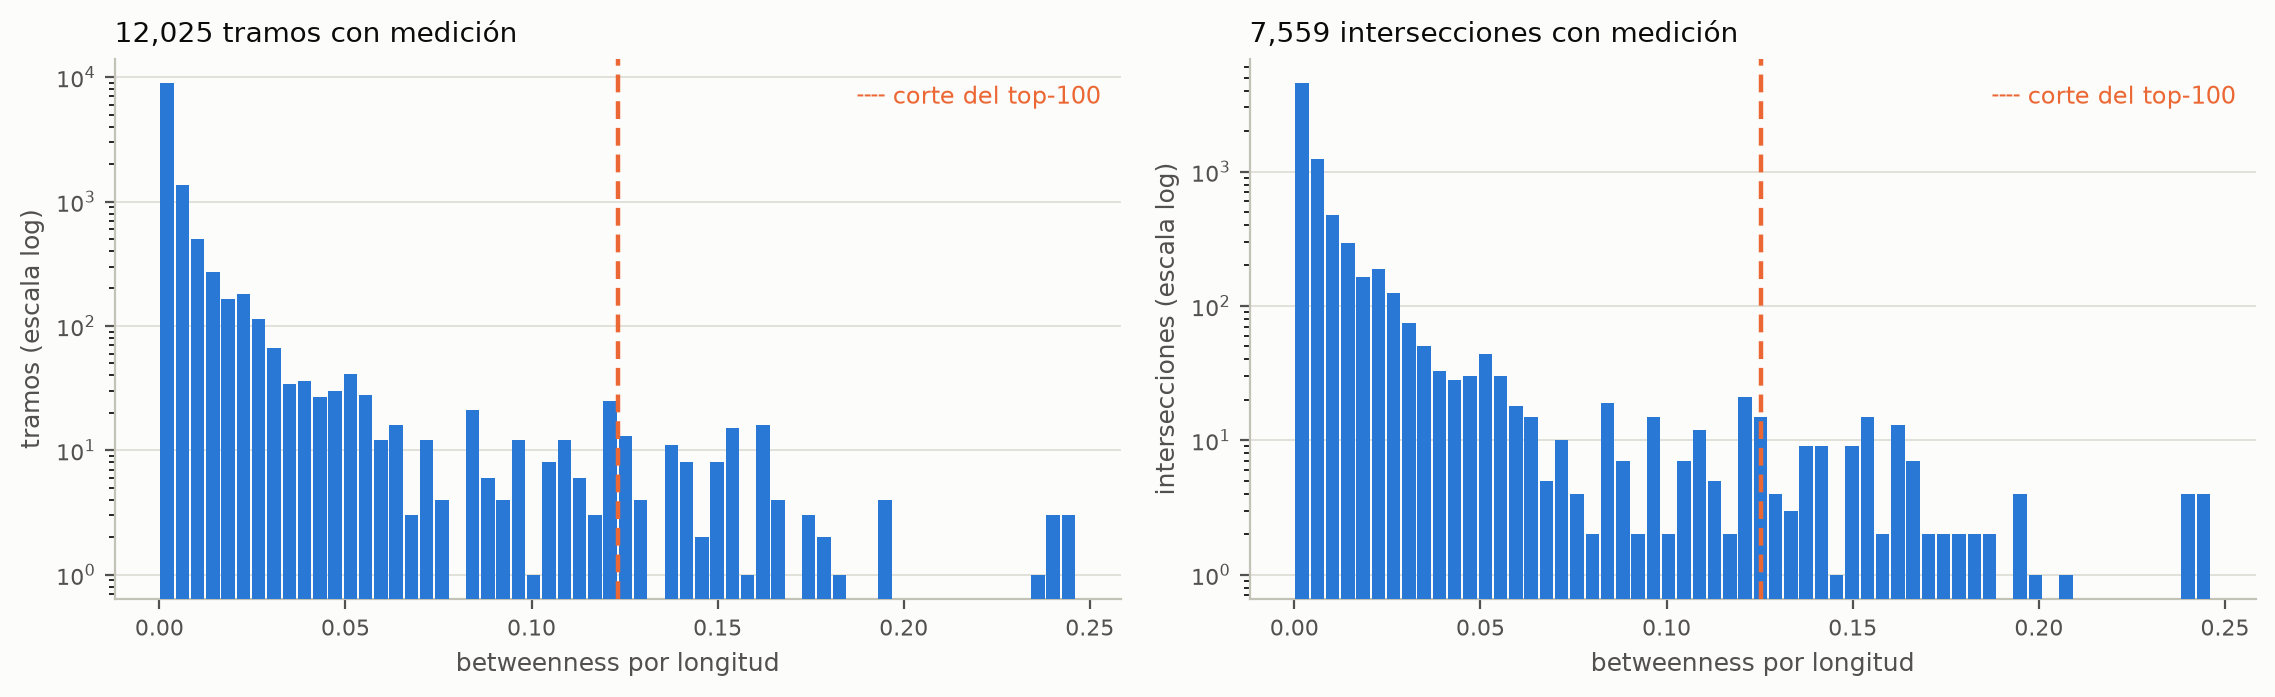

In [ ]:
fig_dist, _axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
fig_dist.patch.set_facecolor(SUPERFICIE)

_paneles = (
    ("tramos", tramos_bc, top_tramos, "tramo_id"),
    ("intersecciones", inter_bc, top_inter, "node_id"),
)
for _ax, (_nombre, _tabla, _top, _clave) in zip(_axes, _paneles, strict=True):
    _ax.set_facecolor(SUPERFICIE)
    _valores = _tabla[COLUMNA].to_numpy(dtype=float)
    _finitos = _valores[np.isfinite(_valores)]
    _ax.hist(_finitos, bins=60, rwidth=0.88, color="#2a78d6", zorder=3)
    _corte = float(_top[COLUMNA].min())
    _ax.axvline(_corte, color="#eb6834", lw=1.6, linestyle=(0, (4, 2)), zorder=4)
    # La etiqueta del corte va anclada a la esquina del panel, no a la línea: el
    # corte se mueve con el deslizador y pegada a la línea se monta encima del
    # título o se sale del recuadro en cuanto el top es chico.
    _ax.text(0.98, 0.95, f"╌╌ corte del top-{len(_top)}", transform=_ax.transAxes,
             color="#eb6834", fontsize=8.5, ha="right", va="top")
    _ax.set_yscale("log")
    _ax.set_xlabel(f"betweenness por {ETIQUETA_PESO}", color=TINTA_2, fontsize=9)
    _ax.set_ylabel(f"{_nombre} (escala log)", color=TINTA_2, fontsize=9)
    _ax.set_title(f"{len(_finitos):,} {_nombre} con medición", color=TINTA,
                  fontsize=10, loc="left")
    # Lo que no tiene dato no entra al histograma, pero tampoco desaparece: se dice.
    _faltan = int(len(_valores) - len(_finitos))
    if _faltan:
        _ax.text(0.98, 0.84, f"+{_faltan:,} sin medición, fuera del histograma",
                 transform=_ax.transAxes, color=MUTE, fontsize=8,
                 ha="right", va="top")
    _ax.grid(axis="y", color=REJILLA, lw=0.7, zorder=0)
    _ax.tick_params(colors=TINTA_2, labelsize=8)
    _ax.spines[["top", "right"]].set_visible(False)
    for _lado in ("left", "bottom"):
        _ax.spines[_lado].set_color("#c3c2b7")
fig_dist.tight_layout()
fig_dist

In [ ]:
# Guardia contra una separación silenciosa: el artefacto `ranking_*` fija el top-100
# con el mismo criterio, y acá el top se deriva de la tabla de betweenness. Si las
# dos rutas dejaran de coincidir, el notebook estaría mostrando otro ranking que el
# que el registro canónico midió.
def _coincide(derivado, artefacto, clave):
    _n = min(len(derivado), len(artefacto))
    if _n == 0:
        return "sin filas que comparar"
    _a = list(derivado[clave].astype(str).head(_n))
    _b = list(artefacto.sort_values("rango")[clave].astype(str).head(_n))
    return f"{sum(x == y for x, y in zip(_a, _b, strict=True))}/{_n} en el mismo puesto"

mo.md(
    f"""
    Contra el artefacto de ranking (top-100, mismo desempate):
    tramos **{_coincide(top_tramos, rankings[f"tramos_{peso.value}"], "tramo_id")}**,
    intersecciones
    **{_coincide(top_inter, rankings[f"intersecciones_{peso.value}"], "node_id")}**
    — comparando hasta donde llegan las dos listas, con la columna `{COLUMNA}`.
    """
)

Contra el artefacto de ranking (top-100, mismo desempate):
tramos **100/100 en el mismo puesto**,
intersecciones
**100/100 en el mismo puesto**
— comparando hasta donde llegan las dos listas, con la columna `bc_length`.

In [ ]:
mo.md(
    f"""
    ## 4 · Las intersecciones críticas, con las estaciones y los estadios encima

    Las {top.value} intersecciones de mayor betweenness por **{ETIQUETA_PESO}**, y
    sobre ellas las estaciones del Metropolitano y de la Línea 1 y los dos estadios
    del área. La pregunta que el mapa deja hacer es si los cruces que la red obliga a
    usar son los mismos donde el transporte masivo deposita gente.
    """
)

## 4 · Las intersecciones críticas, con las estaciones y los estadios encima

Las 100 intersecciones de mayor betweenness por **longitud**, y
sobre ellas las estaciones del Metropolitano y de la Línea 1 y los dos estadios
del área. La pregunta que el mapa deja hacer es si los cruces que la red obliga a
usar son los mismos donde el transporte masivo deposita gente.

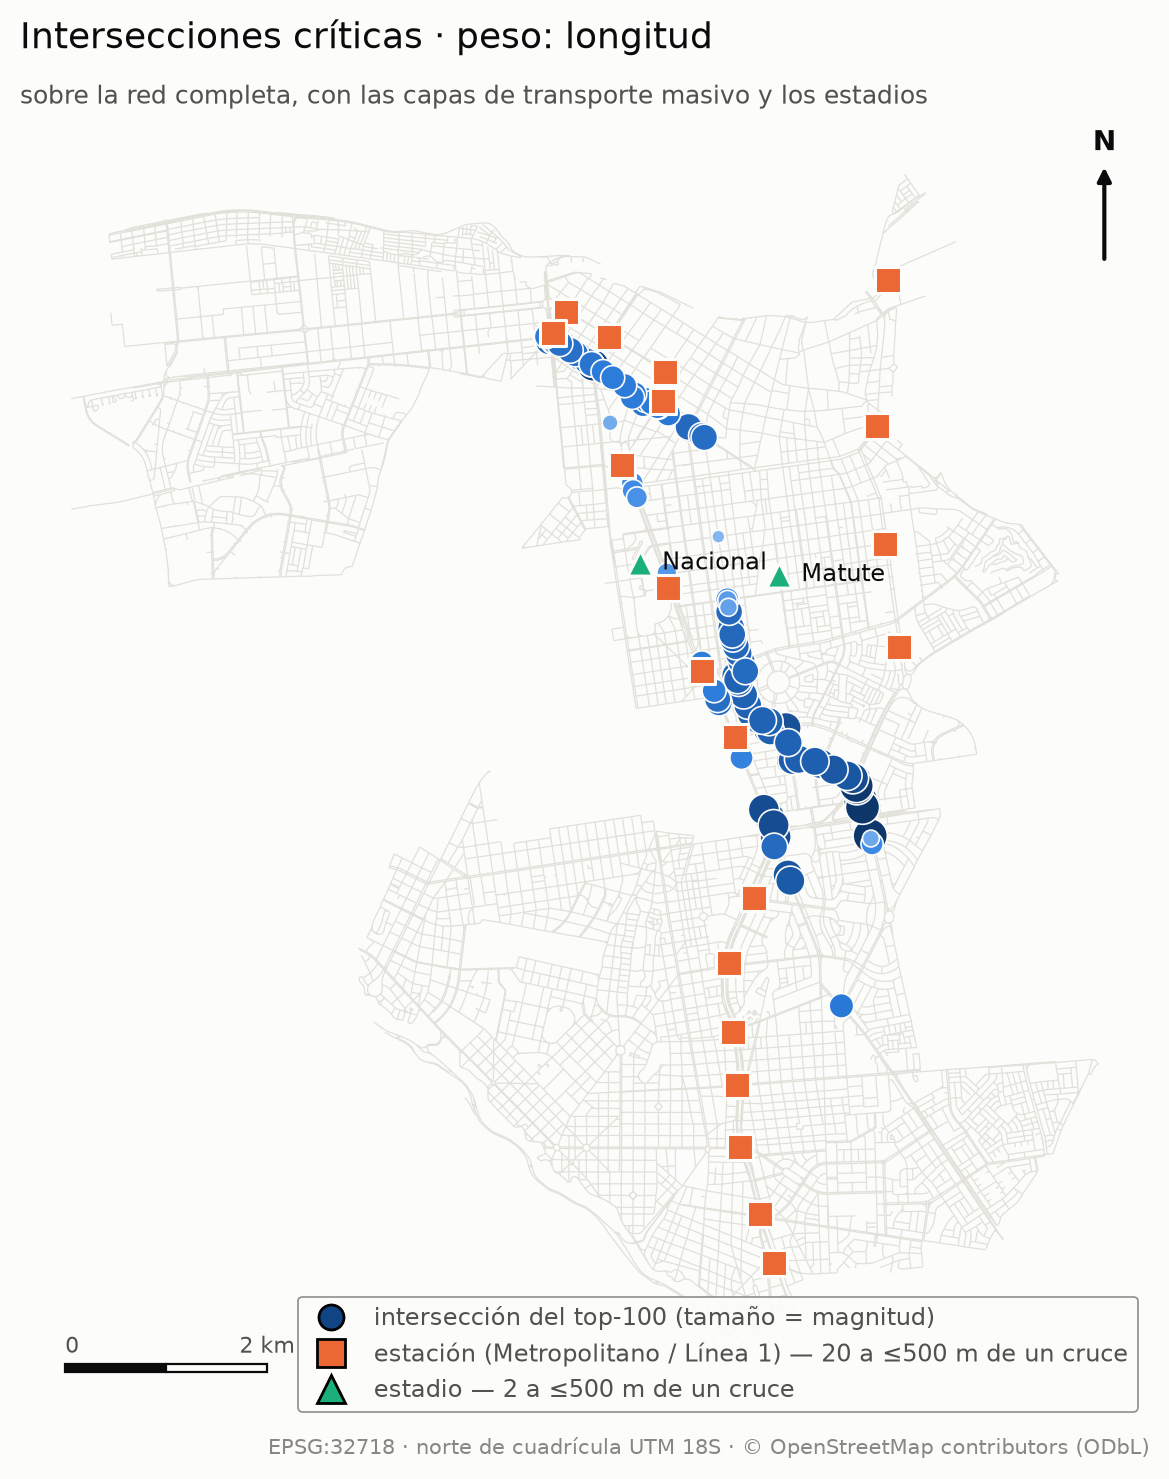

In [ ]:
fig_hubs, _ax = marco_mapa()
# La red entera como contexto, en el gris de rejilla: está para ubicar, no para leer.
tramos_bc.plot(ax=_ax, color=REJILLA, linewidth=0.45, zorder=1)

# `top_inter` ya trae `x` e `y`: sale de la tabla de intersecciones, que las tiene.
# `_xy` es para las capas de puntos, que solo guardan el `node_id` asignado.
_xy = inter_bc.set_index("node_id")[["x", "y"]]
_v = vista.normalizar(top_inter[COLUMNA], gamma=vista.GAMMA_BC)
_ax.scatter(top_inter["x"], top_inter["y"], s=22 + 130 * _v,
            c=[CMAP(PISO_PUNTO + (1 - PISO_PUNTO) * x) for x in _v],
            edgecolors="#fcfcfb", linewidths=0.6, zorder=4)

# Solo los puntos que sí tienen una intersección cerca. El resto no se dibuja en una
# posición inventada: se cuenta abajo.
_cerca = capas_nodos[~capas_nodos["fuera_de_rango"]].merge(
    _xy, left_on="node_id", right_index=True, how="left"
)
_entradas = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=CMAP(0.9),
           markersize=9,
           label=f"intersección del top-{len(top_inter)} (tamaño = magnitud)"),
]
ROTULO_CAPA = {"estacion": "estación (Metropolitano / Línea 1)", "estadio": "estadio"}
for _capa, _color in COLOR_CAPA.items():
    _puntos = _cerca[_cerca["capa"] == _capa]
    _ax.scatter(_puntos["x"], _puntos["y"], marker=FORMA_CAPA[_capa], s=82,
                facecolors=_color, edgecolors="#fcfcfb", linewidths=1.1, zorder=5)
    _entradas.append(
        Line2D([0], [0], marker=FORMA_CAPA[_capa], color="none",
               markerfacecolor=_color, markersize=10,
               label=f"{ROTULO_CAPA[_capa]} — {len(_puntos)} a ≤500 m de un cruce")
    )
    # Los estadios son dos: van rotulados. Es la etiqueta directa que el contraste
    # del aqua contra la superficie exige, y de paso el mapa se lee sin la leyenda.
    if _capa == "estadio":
        for _, _fila in _puntos.iterrows():
            _ax.annotate(_fila["nombre"], (_fila["x"], _fila["y"]), color=TINTA,
                         fontsize=8.5, ha="left", va="center",
                         xytext=(8, 0), textcoords="offset points", zorder=6)

escala_y_norte(
    _ax,
    titulo=f"Intersecciones críticas · peso: {ETIQUETA_PESO}",
    subtitulo="sobre la red completa, con las capas de transporte masivo y los estadios",
)
leyenda(_ax, _entradas)
fig_hubs

In [ ]:
_fuera = int(capas_nodos["fuera_de_rango"].sum())
_cob_nodos = 100 * vista.cobertura(top_inter["node_id"].astype(str), nodos_con_capa)
_cob_tramos = 100 * vista.cobertura(top_tramos["tramo_id"].astype(str), tramos_con_capa)
mo.md(
    f"""
    Con el peso en **{ETIQUETA_PESO}** y este tamaño de top, el
    **{_cob_nodos:.0f} %** de las intersecciones críticas tiene una estación o un
    estadio a menos de 500 m, y el **{_cob_tramos:.0f} %** de los tramos críticos cae
    dentro del buffer de 300 m de alguno. Las dos cifras se recalculan con el
    deslizador: son lecturas del artefacto para *este* corte, no la cifra canónica del
    top-100 que el registro ancla.

    {"" if not _fuera else f"**{_fuera} punto(s) quedaron fuera de rango**: su "
     "intersección más cercana está a más de 500 m, así que no se dibujan. Colgarlos "
     "del cruce del borde fabricaría una asociación que nadie midió."}
    """
)

Con el peso en **longitud** y este tamaño de top, el
**0 %** de las intersecciones críticas tiene una estación o un
estadio a menos de 500 m, y el **26 %** de los tramos críticos cae
dentro del buffer de 300 m de alguno. Las dos cifras se recalculan con el
deslizador: son lecturas del artefacto para *este* corte, no la cifra canónica del
top-100 que el registro ancla.

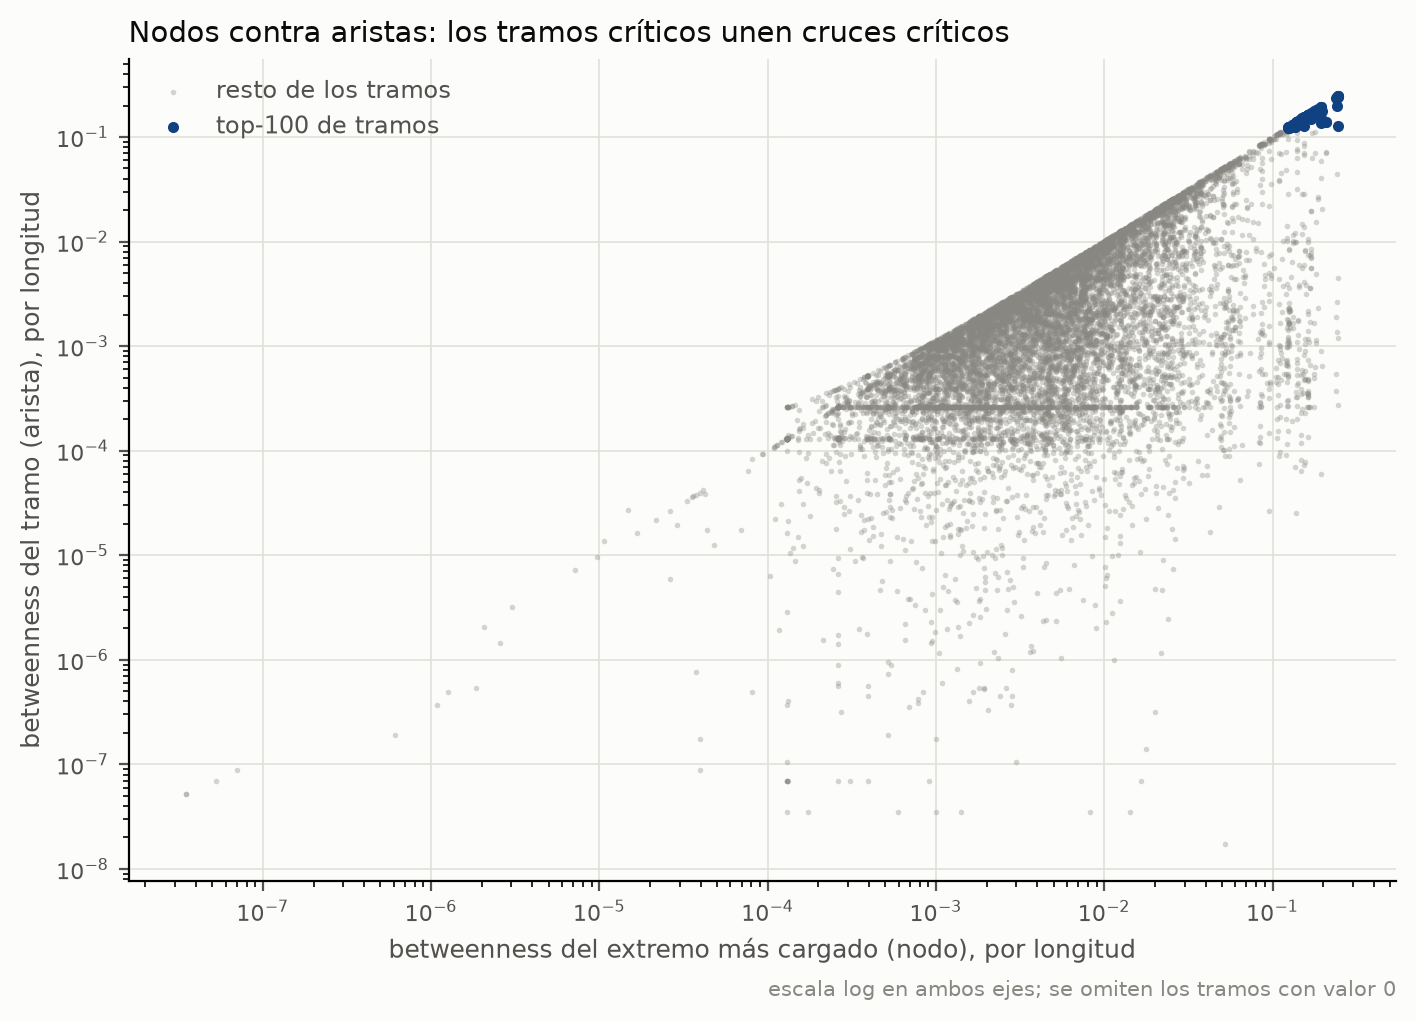

In [ ]:
# ── Betweenness de nodos contra la de aristas ─────────────────────────────
# Para cada tramo, la betweenness de su extremo más cargado. Si los corredores fueran
# "puentes sueltos", habría tramos altos entre cruces bajos; la nube dice si pasa.
_bc_nodo = inter_bc.set_index("node_id")[COLUMNA]
_t = tramos_bc[["tramo_id", "u", "v", COLUMNA]].dropna(subset=[COLUMNA]).copy()
_t["extremo"] = np.fmax(_t["u"].astype(str).map(_bc_nodo).to_numpy(dtype=float),
                        _t["v"].astype(str).map(_bc_nodo).to_numpy(dtype=float))
_t = _t[(_t[COLUMNA] > 0) & (_t["extremo"] > 0)]
_es_top = _t["tramo_id"].isin(set(top_tramos["tramo_id"]))

fig_nodos_aristas, _ax = plt.subplots(figsize=(7.2, 5.2))
fig_nodos_aristas.patch.set_facecolor(SUPERFICIE)
_ax.set_facecolor(SUPERFICIE)
_ax.scatter(_t.loc[~_es_top, "extremo"], _t.loc[~_es_top, COLUMNA], s=4, color=MUTE,
            alpha=0.35, linewidths=0, label="resto de los tramos", zorder=2)
_ax.scatter(_t.loc[_es_top, "extremo"], _t.loc[_es_top, COLUMNA], s=16,
            color="#104281", linewidths=0, label=f"top-{len(top_tramos)} de tramos",
            zorder=3)
_ax.set_xscale("log")
_ax.set_yscale("log")
_ax.set_xlabel(f"betweenness del extremo más cargado (nodo), por {ETIQUETA_PESO}",
               color=TINTA_2, fontsize=9)
_ax.set_ylabel(f"betweenness del tramo (arista), por {ETIQUETA_PESO}", color=TINTA_2,
               fontsize=9)
_ax.set_title("Nodos contra aristas: los tramos críticos unen cruces críticos",
              color=TINTA, fontsize=10.5, loc="left")
_ax.grid(color=REJILLA, lw=0.6, zorder=0)
_ax.tick_params(colors=TINTA_2, labelsize=8)
_ax.spines[["top", "right"]].set_visible(False)
_ax.legend(frameon=False, fontsize=8.5, labelcolor=TINTA_2, loc="upper left")
_ax.text(1.0, -0.14, "escala log en ambos ejes; se omiten los tramos con valor 0",
         transform=_ax.transAxes, color=MUTE, fontsize=7.5, ha="right")
_clave = f"corredores.pct.top_tramos_entre_hubs_{peso.value}"
fig_nodos_aristas.tight_layout()
nodos_aristas = (fig_nodos_aristas, canon.display(_clave))
fig_nodos_aristas

In [ ]:
mo.md(
    f"""
    Con el peso en **{ETIQUETA_PESO}**, el **{nodos_aristas[1]} %** de los 100
    tramos de mayor betweenness tiene sus **dos** extremos entre las 100
    intersecciones de mayor betweenness (cifra del registro, top-100 fijo). Los
    corredores no son puentes sueltos entre cruces irrelevantes: son cadenas de
    cruces críticos, una columna vertebral.
    """
)

Con el peso en **longitud**, el **91.0 %** de los 100
tramos de mayor betweenness tiene sus **dos** extremos entre las 100
intersecciones de mayor betweenness (cifra del registro, top-100 fijo). Los
corredores no son puentes sueltos entre cruces irrelevantes: son cadenas de
cruces críticos, una columna vertebral.

In [ ]:
mo.md(
    f"""
    ## 5 · ¿Coincide con lo que OSM ya llama arterial?

    Si los corredores de la betweenness fueran exactamente las vías que OSM declara
    `motorway`, `trunk` o `primary`, el cálculo no aportaría nada. Las arterias
    declaradas son el **{canon.display("corredores.pct.arterial_declarada_tramos")} %**
    de los tramos: esa es la **tasa base**, lo que acertaría un top elegido al azar.
    Del top-100 por longitud, el
    **{canon.display("corredores.pct.precision_top100_length")} %** es arteria
    declarada, y por tiempo el
    **{canon.display("corredores.pct.precision_top100_travel_time")} %**:
    {canon.display("corredores.pct.exceso_sobre_base_top100_length")} y
    {canon.display("corredores.pct.exceso_sobre_base_top100_travel_time")} puntos sobre
    la tasa base. Hay concentración real, pero cuatro de cada cinco tramos críticos por
    longitud **no** están declarados arteriales: son corredores de hecho que la
    clasificación no reconoce, y son el hallazgo. En el mapa van en negro.
    """
)

## 5 · ¿Coincide con lo que OSM ya llama arterial?

Si los corredores de la betweenness fueran exactamente las vías que OSM declara
`motorway`, `trunk` o `primary`, el cálculo no aportaría nada. Las arterias
declaradas son el **12.5 %**
de los tramos: esa es la **tasa base**, lo que acertaría un top elegido al azar.
Del top-100 por longitud, el
**20.0 %** es arteria
declarada, y por tiempo el
**28.0 %**:
7.5 y
15.5 puntos sobre
la tasa base. Hay concentración real, pero cuatro de cada cinco tramos críticos por
longitud **no** están declarados arteriales: son corredores de hecho que la
clasificación no reconoce, y son el hallazgo. En el mapa van en negro.

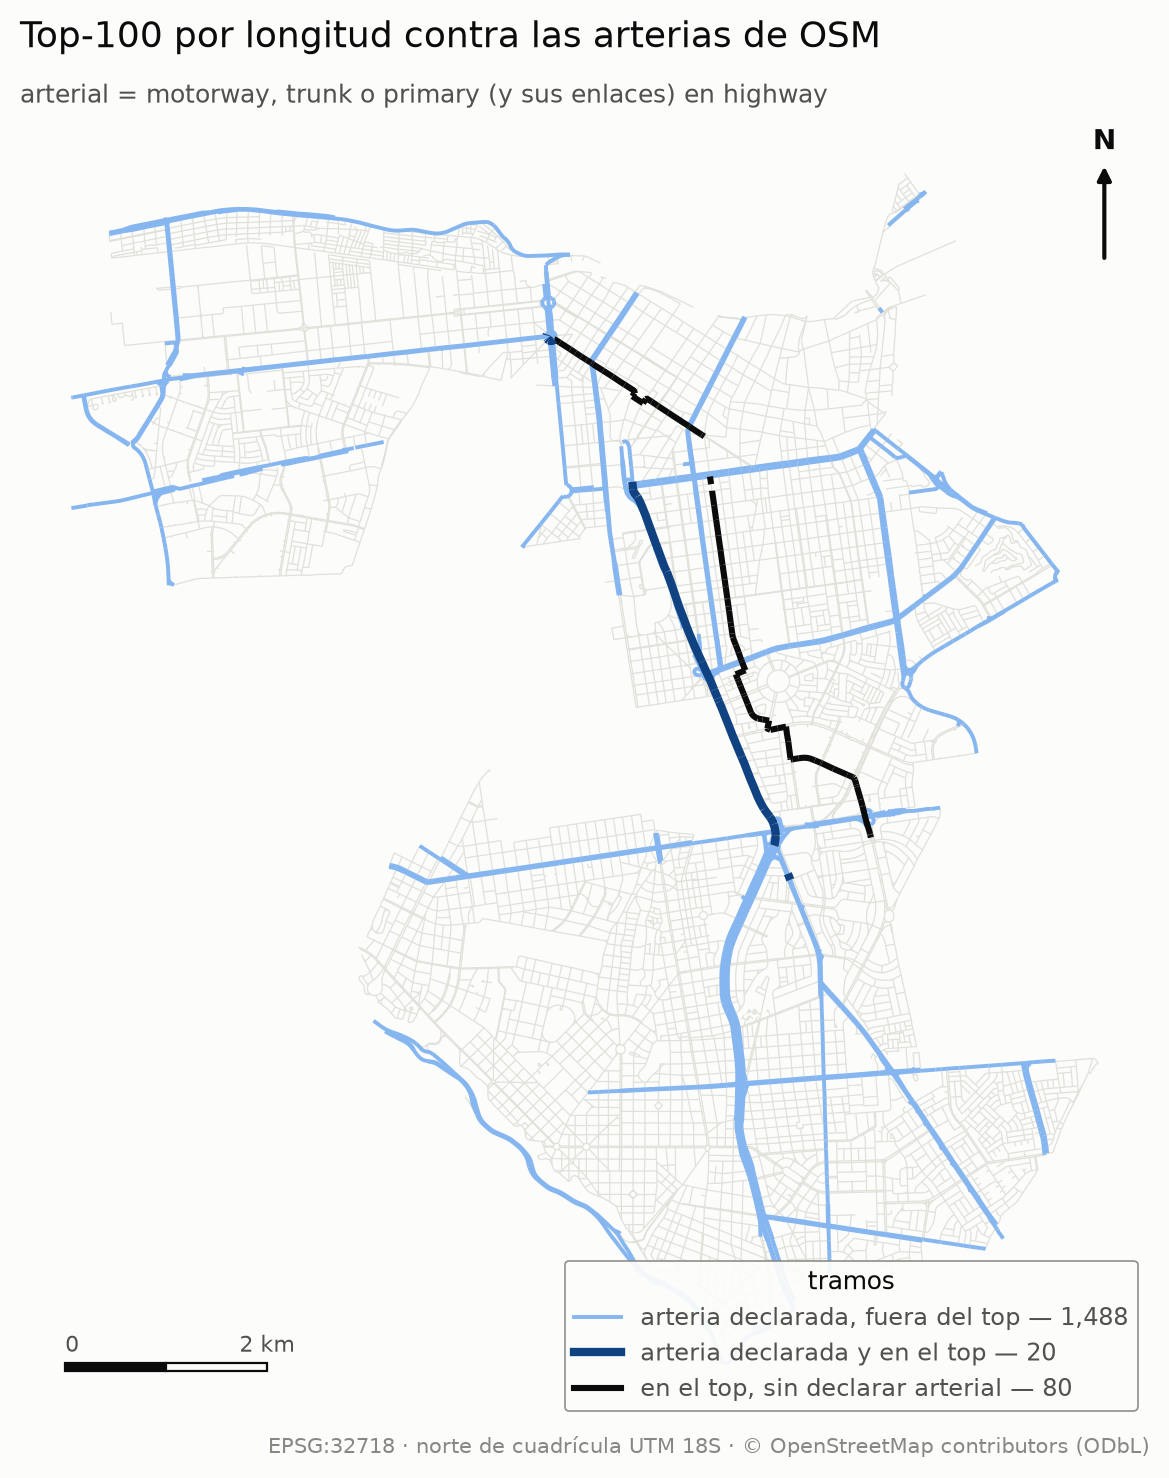

In [ ]:
_arterial = set(arterias_cls.loc[arterias_cls["arterial"], "tramo_id"])
_top = set(top_tramos["tramo_id"])
_cat = tramos_bc["tramo_id"].map(
    lambda t: ("ambos" if t in _top and t in _arterial else
               "solo top" if t in _top else
               "solo arterial" if t in _arterial else "resto")
)
fig_arterias, _ax = marco_mapa()
tramos_bc[_cat == "resto"].plot(ax=_ax, color=REJILLA, linewidth=0.45, zorder=1)
_estilo = {
    "solo arterial": (COLOR_CLASE["local"], 1.4, 2),
    "ambos": (COLOR_CLASE["arterial"], 3.0, 4),
    "solo top": (TINTA, 2.2, 3),
}
_rotulo = {
    "solo arterial": "arteria declarada, fuera del top",
    "ambos": "arteria declarada y en el top",
    "solo top": "en el top, sin declarar arterial",
}
_entradas = []
for _c, (_color, _ancho, _z) in _estilo.items():
    _sel = tramos_bc[_cat == _c]
    if not _sel.empty:
        _sel.plot(ax=_ax, color=_color, linewidth=_ancho, zorder=_z)
    _entradas.append(Line2D([0], [0], color=_color, lw=max(_ancho, 1.4),
                            label=f"{_rotulo[_c]} — {len(_sel):,}"))
escala_y_norte(
    _ax,
    titulo=f"Top-{len(top_tramos)} por {ETIQUETA_PESO} contra las arterias de OSM",
    subtitulo="arterial = motorway, trunk o primary (y sus enlaces) en highway",
)
leyenda(_ax, _entradas, titulo="tramos")
fig_arterias

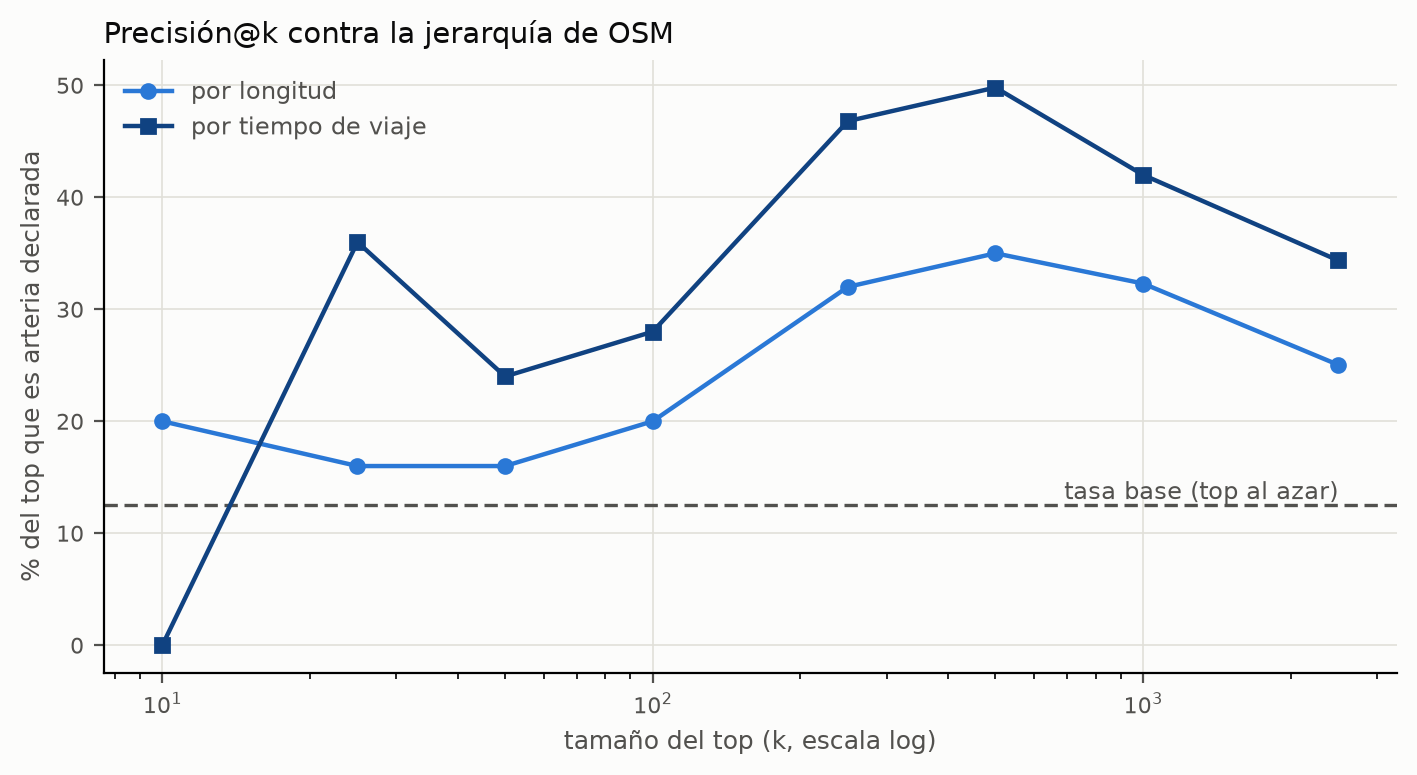

In [ ]:
fig_curva, _ax = plt.subplots(figsize=(7.2, 4.0))
fig_curva.patch.set_facecolor(SUPERFICIE)
_ax.set_facecolor(SUPERFICIE)
_estilos = {"length": ("#2a78d6", "o", "por longitud"),
            "travel_time": ("#104281", "s", "por tiempo de viaje")}
for _peso, (_color, _marca, _rot) in _estilos.items():
    _c = arterias_curva[arterias_curva["peso"] == _peso].sort_values("k")
    _ax.plot(_c["k"], _c["precision"], color=_color, marker=_marca, ms=5, lw=1.6,
             label=_rot, zorder=3)
_base = float(arterias_curva["tasa_base"].iloc[0])
_ax.axhline(_base, color=TINTA_2, lw=1.2, linestyle=(0, (4, 2)), zorder=2)
_ax.text(arterias_curva["k"].max(), _base, "  tasa base (top al azar)",
         color=TINTA_2, fontsize=8.5, va="bottom", ha="right")
_ax.set_xscale("log")
_ax.set_xlabel("tamaño del top (k, escala log)", color=TINTA_2, fontsize=9)
_ax.set_ylabel("% del top que es arteria declarada", color=TINTA_2, fontsize=9)
_ax.set_title("Precisión@k contra la jerarquía de OSM", color=TINTA, fontsize=10.5,
              loc="left")
_ax.grid(color=REJILLA, lw=0.6, zorder=0)
_ax.tick_params(colors=TINTA_2, labelsize=8)
_ax.spines[["top", "right"]].set_visible(False)
_ax.legend(frameon=False, fontsize=8.5, labelcolor=TINTA_2)
fig_curva.tight_layout()
fig_curva

## 6 · El ranking

La tabla de lo crítico, con el puesto que cada unidad ocupa bajo **los dos** pesos
al mismo tiempo. Ahí se ve el hallazgo sin tener que mover nada: filas que están
arriba por longitud y muy abajo por tiempo, y al revés.

In [ ]:
def _puesto(valores):
    # El rango del OTRO peso puede ser NaN: una unidad puede no tener medición por
    # tiempo y sí por longitud. Un `astype(int)` ahí revienta la tabla, y un 0 diría
    # "primer puesto". Se dice que falta.
    return [("sin dato" if pd.isna(r) else f"{int(r)}") for r in valores]

def _presentar(top_, *, clave, capas, extra):
    cerca = vista.nombres_cercanos(top_[clave].astype(str), capas, clave=clave)
    salida = pd.DataFrame({
        "puesto": top_["rango"],
        clave: top_[clave].astype(str),
        "betweenness": top_[COLUMNA].map(lambda v: f"{v:.5f}"),
        "puesto por longitud": _puesto(top_["rango_length"]),
        "puesto por tiempo": _puesto(top_["rango_travel_time"]),
    })
    for etiqueta, columna in extra.items():
        salida[etiqueta] = columna
    salida["estación o estadio cerca"] = [
        cerca[k] or "—" for k in top_[clave].astype(str)
    ]
    return salida

# `reindex().fillna()` y no `.get(k) or …`: un `NaN` de pandas es *truthy* en Python,
# así que el `or` lo dejaría pasar y la tabla mostraría "nan" donde OSM no puso nombre.
_calles = (
    tramos_bc.set_index("tramo_id")["name"]
    .reindex(top_tramos["tramo_id"]).fillna("sin nombre").tolist()
)
_cruces = (
    inter_bc.set_index("node_id")["street_count"]
    .reindex(top_inter["node_id"]).fillna("—").tolist()
    if "street_count" in inter_bc
    else ["—"] * len(top_inter)
)

mo.ui.tabs({
    "tramos": mo.ui.table(
        _presentar(top_tramos, clave="tramo_id", capas=capas_tramos,
                   extra={"calle": _calles}),
        selection=None, page_size=15,
    ),
    "intersecciones": mo.ui.table(
        # Sin los puntos fuera de rango: su `node_id` es el del cruce más cercano,
        # pero a más de medio kilómetro. Contarlo como "cerca" sería mentir.
        _presentar(top_inter, clave="node_id",
                   capas=capas_nodos[~capas_nodos["fuera_de_rango"]],
                   extra={"calles que cruzan": _cruces}),
        selection=None, page_size=15,
    ),
})

&lt;marimo-tabs data-initial-value=&#x27;&amp;quot;&amp;quot;&#x27; data-label=&#x27;null&#x27; data-tabs=&#x27;[&amp;quot;&amp;#92;u003cspan class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;#92;u003e&amp;#92;u003cspan class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;#92;u003etramos&amp;#92;u003c/span&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;quot;,&amp;quot;&amp;#92;u003cspan class=&amp;#92;&amp;quot;markdown prose dark:prose-invert contents&amp;#92;&amp;quot;&amp;#92;u003e&amp;#92;u003cspan class=&amp;#92;&amp;quot;paragraph&amp;#92;&amp;quot;&amp;#92;u003eintersecciones&amp;#92;u003c/span&amp;#92;u003e&amp;#92;u003c/span&amp;#92;u003e&amp;quot;]&#x27; data-orientation=&#x27;&amp;quot;horizontal&amp;quot;&#x27;&gt;&lt;div data-kind=&#x27;tab&#x27;&gt;&lt;marimo-ui-element object-id=&#x27;TRpd-0&#x27; random-id=&#x27;f667a839-9505-c87a-9d1b-c1a41c955ff8&#x27;&gt;&lt;marimo-table data-initial-value=&#x27;[]&#x27; data-label=&#x27;null&#x27; data-data=&#x27;&amp;quot;[{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:1,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;10717775324-392153249-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24633&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;1&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;2&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:2,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153275-475767951-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24540&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;2&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153249-392153275-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24512&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;3&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;5&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:4,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;475767951-9307357723-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24092&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;7&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:5,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153681-411852350-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.23923&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;5&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;8&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:6,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4570857564-9307357723-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.23826&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;6&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;10&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:7,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153681-4570857564-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.23788&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;7&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;9&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Jos&amp;#92;&amp;#92;u00e9 G&amp;#92;&amp;#92;u00e1lvez Barrenechea&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:8,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;411852350-411935448-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19649&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;8&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;50&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida San Eugenio&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:9,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4003442656-4003442657-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19505&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;9&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;13&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;V&amp;#92;&amp;#92;u00eda Expresa Luis Fern&amp;#92;&amp;#92;u00e1n Bedoya Reyes&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:10,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;263106951-316626660-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19422&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;10&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;14&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;V&amp;#92;&amp;#92;u00eda Expresa Luis Fern&amp;#92;&amp;#92;u00e1n Bedoya Reyes&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:11,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;263106951-4003442657-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19416&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;11&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;15&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;V&amp;#92;&amp;#92;u00eda Expresa Luis Fern&amp;#92;&amp;#92;u00e1n Bedoya Reyes&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:12,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;408630130-411852333-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.18403&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;12&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;34&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida Canad&amp;#92;&amp;#92;u00e1&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:13,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;13006613775-411852347-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.17981&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;13&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;45&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida San Eugenio&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:14,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;411852349-411935448-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.17660&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;14&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;51&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida San Eugenio&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:15,&amp;#92;&amp;quot;tramo_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;411852348-411852349-0&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.17620&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;15&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;60&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calle&amp;#92;&amp;quot;:&amp;#92;&amp;quot;Avenida San Eugenio&amp;#92;&amp;quot;,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;}]&amp;quot;&#x27; data-total-rows=&#x27;100&#x27; data-total-columns=&#x27;7&#x27; data-max-columns=&#x27;50&#x27; data-banner-text=&#x27;&amp;quot;&amp;quot;&#x27; data-pagination=&#x27;true&#x27; data-page-size=&#x27;15&#x27; data-field-types=&#x27;[[&amp;quot;puesto&amp;quot;,[&amp;quot;integer&amp;quot;,&amp;quot;int64&amp;quot;]],[&amp;quot;tramo_id&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;betweenness&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;puesto por longitud&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;puesto por tiempo&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;calle&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;estación o estadio cerca&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]]]&#x27; data-show-filters=&#x27;true&#x27; data-show-download=&#x27;true&#x27; data-show-search=&#x27;true&#x27; data-show-column-summaries=&#x27;true&#x27; data-show-data-types=&#x27;true&#x27; data-show-page-size-selector=&#x27;true&#x27; data-show-column-explorer=&#x27;true&#x27; data-show-chart-builder=&#x27;true&#x27; data-row-headers=&#x27;[]&#x27; data-hidden-columns=&#x27;[]&#x27; data-has-stable-row-id=&#x27;false&#x27; data-lazy=&#x27;false&#x27; data-preload=&#x27;false&#x27;&gt;&lt;/marimo-table&gt;&lt;/marimo-ui-element&gt;&lt;/div&gt;&lt;div data-kind=&#x27;tab&#x27;&gt;&lt;marimo-ui-element object-id=&#x27;TRpd-1&#x27; random-id=&#x27;b61b37c8-86b9-3f51-cd46-124d8a040ada&#x27;&gt;&lt;marimo-table data-initial-value=&#x27;[]&#x27; data-label=&#x27;null&#x27; data-data=&#x27;&amp;quot;[{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:1,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153249&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24626&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;1&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;3&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:2,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;10717775324&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24626&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;2&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;475767951&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24533&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;3&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;7&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:4,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153275&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24533&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;8&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:5,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;9307357723&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24086&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;5&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;10&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:6,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;411852350&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.24053&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;6&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;9&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:4,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:7,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;392153681&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.23970&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;7&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;11&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:4,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:8,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4570857564&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.23819&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;8&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;12&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:9,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;582805030&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.20927&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;9&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;60&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:4,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:10,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;411935448&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19706&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;10&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;64&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:4,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:11,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4003442657&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19497&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;11&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;16&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:12,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;4003442656&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19497&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;12&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;17&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:13,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;316626660&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19414&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;13&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;18&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:14,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;263106951&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.19414&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;14&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;19&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;},{&amp;#92;&amp;quot;puesto&amp;#92;&amp;quot;:15,&amp;#92;&amp;quot;node_id&amp;#92;&amp;quot;:&amp;#92;&amp;quot;408630130&amp;#92;&amp;quot;,&amp;#92;&amp;quot;betweenness&amp;#92;&amp;quot;:&amp;#92;&amp;quot;0.18720&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por longitud&amp;#92;&amp;quot;:&amp;#92;&amp;quot;15&amp;#92;&amp;quot;,&amp;#92;&amp;quot;puesto por tiempo&amp;#92;&amp;quot;:&amp;#92;&amp;quot;42&amp;#92;&amp;quot;,&amp;#92;&amp;quot;calles que cruzan&amp;#92;&amp;quot;:3,&amp;#92;&amp;quot;estaci&amp;#92;&amp;#92;u00f3n o estadio cerca&amp;#92;&amp;quot;:&amp;#92;&amp;quot;&amp;#92;&amp;#92;u2014&amp;#92;&amp;quot;}]&amp;quot;&#x27; data-total-rows=&#x27;100&#x27; data-total-columns=&#x27;7&#x27; data-max-columns=&#x27;50&#x27; data-banner-text=&#x27;&amp;quot;&amp;quot;&#x27; data-pagination=&#x27;true&#x27; data-page-size=&#x27;15&#x27; data-field-types=&#x27;[[&amp;quot;puesto&amp;quot;,[&amp;quot;integer&amp;quot;,&amp;quot;int64&amp;quot;]],[&amp;quot;node_id&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;betweenness&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;puesto por longitud&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;puesto por tiempo&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]],[&amp;quot;calles que cruzan&amp;quot;,[&amp;quot;integer&amp;quot;,&amp;quot;int64&amp;quot;]],[&amp;quot;estación o estadio cerca&amp;quot;,[&amp;quot;string&amp;quot;,&amp;quot;str&amp;quot;]]]&#x27; data-show-filters=&#x27;true&#x27; data-show-download=&#x27;true&#x27; data-show-search=&#x27;true&#x27; data-show-column-summaries=&#x27;true&#x27; data-show-data-types=&#x27;true&#x27; data-show-page-size-selector=&#x27;true&#x27; data-show-column-explorer=&#x27;true&#x27; data-show-chart-builder=&#x27;true&#x27; data-row-headers=&#x27;[]&#x27; data-hidden-columns=&#x27;[]&#x27; data-has-stable-row-id=&#x27;false&#x27; data-lazy=&#x27;false&#x27; data-preload=&#x27;false&#x27;&gt;&lt;/marimo-table&gt;&lt;/marimo-ui-element&gt;&lt;/div&gt;&lt;/marimo-tabs&gt;

In [ ]:
mo.md(
    f"""
    ## 7 · La limitación que este mapa lleva adentro

    > ### El corredor exclusivo del Metropolitano está dentro del grafo
    > OSM lo etiqueta `highway=busway` y, en casi todas sus vías del área A, también
    > `access=no`: está cerrado al tránsito general. El filtro `drive` de osmnx
    > descarta `access=private` pero no `access=no`, así que esas calzadas entraron.
    > El grupo decidió **mantenerlas y declararlo**, en vez de recortar el grafo y
    > perder la trazabilidad contra la descarga original.
    >
    > Pesa poco en la red y bastante más en el resultado: es el
    > **{canon.display("corredores.pct.busway_tramos")} %** de los tramos y el
    > **{canon.display("corredores.pct.busway_largo")} %** de la longitud, pero se
    > lleva el **{canon.display("corredores.pct.busway_bc_length")} %** de la
    > betweenness por longitud y el
    > **{canon.display("corredores.pct.busway_bc_travel_time")} %** de la
    > betweenness por tiempo de viaje. La diferencia entre esos dos últimos números es
    > el efecto del supuesto: un carril exclusivo y recto es, para el grafo, una vía
    > rápida sin competencia.
    >
    > En el mapa 1 va en naranja, para que se pueda ubicar qué parte de los corredores
    > de arriba se apoya en él.

    ### Lo que sigue sin saberse

    - **No hay aforos.** Todo lo de arriba es flujo potencial: una propiedad de la
      geometría de la red bajo el supuesto de que cualquier par origen-destino es
      igual de probable. En una ciudad real no lo es, y sin una matriz de viajes no
      hay forma de saber cuánto se parece una cosa a la otra.
    - **El peso por tiempo hereda velocidades imputadas** en buena parte de la red.
      Donde la velocidad es un supuesto, el corredor también lo es.
    - **El área A tiene borde**, y un borde recorta caminos: las intersecciones cerca
      del límite pierden los recorridos que salen del área. La betweenness que se ve
      ahí está subestimada, y este notebook no la corrige.
    """
)

## 7 · La limitación que este mapa lleva adentro

> ### El corredor exclusivo del Metropolitano está dentro del grafo
> OSM lo etiqueta `highway=busway` y, en casi todas sus vías del área A, también
> `access=no`: está cerrado al tránsito general. El filtro `drive` de osmnx
> descarta `access=private` pero no `access=no`, así que esas calzadas entraron.
> El grupo decidió **mantenerlas y declararlo**, en vez de recortar el grafo y
> perder la trazabilidad contra la descarga original.
>
> Pesa poco en la red y bastante más en el resultado: es el
> **0.4 %** de los tramos y el
> **0.7 %** de la longitud, pero se
> lleva el **0.1 %** de la
> betweenness por longitud y el
> **1.2 %** de la
> betweenness por tiempo de viaje. La diferencia entre esos dos últimos números es
> el efecto del supuesto: un carril exclusivo y recto es, para el grafo, una vía
> rápida sin competencia.
>
> En el mapa 1 va en naranja, para que se pueda ubicar qué parte de los corredores
> de arriba se apoya en él.

### Lo que sigue sin saberse

- **No hay aforos.** Todo lo de arriba es flujo potencial: una propiedad de la
  geometría de la red bajo el supuesto de que cualquier par origen-destino es
  igual de probable. En una ciudad real no lo es, y sin una matriz de viajes no
  hay forma de saber cuánto se parece una cosa a la otra.
- **El peso por tiempo hereda velocidades imputadas** en buena parte de la red.
  Donde la velocidad es un supuesto, el corredor también lo es.
- **El área A tiene borde**, y un borde recorta caminos: las intersecciones cerca
  del límite pierden los recorridos que salen del área. La betweenness que se ve
  ahí está subestimada, y este notebook no la corrige.